# 🔍 VoltRelay: Stress-Testing Our Own Findings
**Team WindRocker** · Gradient Learnings Data Analytics Hackathon · companion to `VoltRelay_Analysis_WindRocker.ipynb`

The main notebook tells one story: **heat + Gen1 chargers → summer failures, a bad Kyron batch → margin erosion, early bad experiences → churn.** This notebook tries to break that story. For each headline number we ask four questions:

1. **Confounding:** could something else (station load, heat, city, rider activity) produce the same pattern?
2. **Exposure bias:** is a "concentration" just a reflection of who was observed longest?
3. **Double counting:** are two numbers really the same money?
4. **Behavioural response:** does a sizing assume nobody reacts?

Every check runs on the same cleaned data as the main notebook, and every revised number is exported to `outputs/audit_metrics.json`.

### What changed after stress-testing (the answer first)

**The three-part story survives.** Gen1 × heat still drives summer failures, the Kyron batch still drives margin erosion, and early failures still drive churn. Several of our numbers were framed too generously, a few were too cautious, and one explanation did not hold.

| | Claim | Revised view |
|---|---|---|
| ✅ | Gen1 × heat causes summer failures | Holds at every load level. Gen3 sites are actually busier. Outages and offline chargers are ruled out. |
| ⚠️ | "Stop buying Kyron" | Only lots **KY-2407/08/09** are bad. Kyron's later 3W lots wear exactly like Cellora and Amptek. |
| ⚠️ | ₹48M write-off **and** ₹34M/yr excess wear | Same money counted twice. The premature loss is **≈₹28.7M**, and it does not recur once the packs are pulled. |
| ⚠️ | Pricing rollout +₹6.1M a year | Pilot riders swapped **4.6% less often**, so the rollout is worth **≈₹3.7M**. |
| ⚠️ | "Energy saved ₹3.4 per swap" | kWh per swap fell because packs aged. Riders got less energy for the same price. |
| ❌ | "3W fails more because fewer stations have 3W slots" | 3W failure is identical with or without 3W slots. The gap exists all year. |
| ⬆️ | Churn odds ratio for 2+ early failures: 1.58 | **2.05** once early activity is controlled. The published figure is a floor. |
| ➕ | Margin eroded to −₹17.5 per swap | Without the three bad lots it would be **−₹4.2**. About 76% of the loss is one cohort. |
| ➕ | New | Cooling Gen1 cabinets by 5°C would get **~64%** of the Gen3 benefit. Riders never retry after a failure, so failures cost **≈₹14.3M** of revenue over 18 months. |

## 0. Setup
Same loader as the main notebook: Parquet cache if present, otherwise the raw CSV / CSV.GZ files via pyarrow. Works in Google Colab (Drive mount) and locally.

In [1]:
import os, sys, json, time, warnings, subprocess
from pathlib import Path
warnings.filterwarnings("ignore")
IS_COLAB = "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ
try:
    import duckdb
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=True); import duckdb
import numpy as np, pandas as pd
import pyarrow.csv as pacsv
import matplotlib.pyplot as plt, matplotlib.ticker as mtick
import statsmodels.formula.api as smf

if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOTS = [Path("/content/drive/MyDrive/DataAnalyticsHackathon"), Path("/content/drive/MyDrive")]
else:
    ROOTS = [Path.cwd(), Path.cwd().parent]
# The organisers' Drive folder is "Hackathon Data Set | Gradient"; a local download is "... _ Gradient". Either works,
# inside the project folder or as a shortcut at the top of My Drive.
DATA_NAMES = ["Hackathon Data Set _ Gradient", "Hackathon Data Set | Gradient"]
DATA_DIR = next((r / n for r in ROOTS for n in DATA_NAMES if (r / n).exists()), ROOTS[0] / DATA_NAMES[0])
PROJECT = ROOTS[0] if IS_COLAB else next((r for r in ROOTS if (r / "data/parquet").exists() or DATA_DIR.parent == r), ROOTS[0])
PROJECT.mkdir(parents=True, exist_ok=True); os.chdir(PROJECT)
PARQUET = PROJECT / "data/parquet"
if not DATA_DIR.exists() and not PARQUET.exists():
    raise FileNotFoundError("Data not found. Add a shortcut to the organisers' 'Hackathon Data Set | Gradient' folder in "
                            "MyDrive (or MyDrive/DataAnalyticsHackathon), then re-run. Looked in: " + ", ".join(map(str, ROOTS)))
print("Data:", DATA_DIR if DATA_DIR.exists() else PARQUET)
FIG = PROJECT / "outputs/figures"; FIG.mkdir(parents=True, exist_ok=True)
OUT = PROJECT / "outputs"
print("Project:", PROJECT, "| Colab:", IS_COLAB, "| duckdb", duckdb.__version__, "| pandas", pd.__version__)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

Data: C:\Users\siddh\Documents\DataAnalyticsHackathon\Hackathon Data Set _ Gradient
Project: C:\Users\siddh\Documents\DataAnalyticsHackathon | Colab: False | duckdb 1.5.5 | pandas 3.0.6


In [2]:
TABLES = ["swap_events","station_hourly_status","riders","batteries","support_tickets","stations","city_daily_context","fleet_partners"]
con = duckdb.connect()
t0 = time.time()
for t in TABLES:
    pq = PARQUET / f"{t}.parquet"
    if pq.exists():
        con.execute(f"CREATE OR REPLACE TABLE raw_{t} AS SELECT * FROM read_parquet('{pq.as_posix()}')")
    else:
        src = DATA_DIR / f"{t}.csv"
        if not src.exists(): src = DATA_DIR / f"{t}.csv.gz"
        tbl = pacsv.read_csv(src, convert_options=pacsv.ConvertOptions(strings_can_be_null=True, timestamp_parsers=["%Y-%m-%d %H:%M:%S", "%Y-%m-%d"]))
        con.register("tmp_arrow", tbl); con.execute(f"CREATE OR REPLACE TABLE raw_{t} AS SELECT * FROM tmp_arrow"); con.unregister("tmp_arrow"); del tbl
print(f"Loaded in {time.time()-t0:.1f}s")

def q(sql, **kw):
    return con.execute(sql, kw or None).df()

METRICS = {}   # every revised number quoted anywhere comes from here
def keep(key, val):
    METRICS[key] = (round(float(val), 4) if isinstance(val, (float, np.floating)) else (int(val) if isinstance(val, (np.integer,)) else val)); return val
PUBLISHED = json.loads((OUT / "metrics.json").read_text()) if (OUT / "metrics.json").exists() else {}
print(f"{len(PUBLISHED)} published metrics loaded for side-by-side comparison" if PUBLISHED else "metrics.json not found: originals are recomputed here")

Loaded in 1.4s
210 published metrics loaded for side-by-side comparison


In [3]:
BLUE, ORANGE, AQUA, YELLOW, RED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e34948"
GREY, INK, INK2 = "#b9b8b3", "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#8a8984",
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "legend.frameon": False, "lines.linewidth": 2, "font.family": "DejaVu Sans"})
GCOL = {"Gen1": RED, "Gen2": BLUE, "Gen3": AQUA}
import textwrap
def save(fig, name):
    lim = int(fig.get_figwidth() * 9.5)   # wrap insight titles that would run past the plot
    for ax in fig.axes:
        t = ax.get_title(loc="left")
        if len(t) > lim and len(fig.axes) == 1:
            n = -(-len(t) // lim); ax.set_title("\n".join(textwrap.wrap(t, -(-len(t) // n) + 6)), loc="left")
    if fig._suptitle is not None and len(fig._suptitle.get_text()) > lim * 1.1:
        fig._suptitle.set_text("\n".join(textwrap.wrap(fig._suptitle.get_text(), int(lim * 1.1))))
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", facecolor="white"); plt.show()
def pct_axis(ax, axis="y", dec=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(mtick.MaxNLocator(nbins=6, steps=[1, 2, 5, 10])); a.set_major_formatter(mtick.PercentFormatter(100, decimals=dec))
def inr(v): return f"{'−' if v < 0 else ''}₹{abs(v):.1f}"
import matplotlib.dates as mdates
def date_axis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10])); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
HOT = "('Jaipur','Delhi NCR','Hyderabad')"
BAD_LOTS = "('KY-2407','KY-2408','KY-2409')"
PEAK_HOURS = [12, 13, 19, 20, 21, 22]

## 1. Rebuild the cleaned data (identical rules to the main notebook)
- Exclude test stations `STN-TST-01/02`
- Shift firmware v3.2.0 events logged 10 Mar – 14 Apr 2025 by +5h30m (the raw timestamp is kept as `raw_ts` so we can test the fix)
- NULL odometer-reset distances, clip SoC/SoH at 100, standardise rider cities
- Same contribution-margin model: energy at station tariff, battery wear from observed SoH loss to a 70% end-of-life, site rent + maintenance spread over the month's swaps

In [4]:
ALIAS = {"bengaluru":"Bengaluru","bangalore":"Bengaluru","blr":"Bengaluru","delhi ncr":"Delhi NCR","delhi":"Delhi NCR","new delhi":"Delhi NCR","gurgaon":"Delhi NCR",
         "gurugram":"Delhi NCR","noida":"Delhi NCR","del":"Delhi NCR","ncr":"Delhi NCR","mumbai":"Mumbai","bombay":"Mumbai","mum":"Mumbai","pune":"Pune","pun":"Pune",
         "hyderabad":"Hyderabad","hyd":"Hyderabad","jaipur":"Jaipur","jai":"Jaipur"}
raw_c = q("SELECT home_city, COUNT(*) n FROM raw_riders GROUP BY 1")
raw_c["clean"] = raw_c.home_city.str.strip().str.lower().map(ALIAS); assert raw_c.clean.notna().all()
con.register("city_map", raw_c[["home_city", "clean"]])
con.execute("CREATE OR REPLACE TABLE riders AS SELECT r.* EXCLUDE(home_city), m.clean AS home_city FROM raw_riders r JOIN city_map m USING(home_city)")
con.execute("CREATE OR REPLACE TABLE stations AS SELECT * FROM raw_stations WHERE station_id NOT LIKE 'STN-TST%'")
FWFIX = "e.station_firmware='v3.2.0' AND e.event_ts >= '2025-03-10' AND e.event_ts < '2025-04-15'"
con.execute(f'''
CREATE OR REPLACE TABLE sw AS
SELECT e.event_id, e.rider_id, e.station_id,
  CASE WHEN {FWFIX} THEN e.event_ts + INTERVAL 330 MINUTE ELSE e.event_ts END AS ts, e.event_ts AS raw_ts,
  e.event_type, e.queue_wait_sec, e.battery_in_id, e.battery_out_id, e.soc_in_pct AS soc_in,
  LEAST(e.soh_in_pct,100) soh_in, LEAST(e.soc_out_pct,100) soc_out, LEAST(e.soh_out_pct,100) soh_out,
  CASE WHEN e.km_since_last_swap < 0 OR e.km_since_last_swap > 200 THEN NULL ELSE e.km_since_last_swap END AS km,
  e.tariff_code, e.list_price_inr, e.discount_inr, e.amount_charged_inr AS rev, e.energy_to_recharge_kwh AS kwh, e.sync_mode,
  s.city, s.charger_generation gen, s.expansion_wave wave, s.grid_tariff_inr_kwh grid_tariff, s.slots_2w, s.slots_3w,
  r.vehicle_class vc, r.partner_id, r.plan_type, r.signup_date,
  bi.supplier sup_in, bi.pack_type pack_in, bi.manufacturing_lot lot_in, bo.supplier sup_out, bo.manufacturing_lot lot_out,
  (e.event_type IN ('failed_no_charged_battery','abandoned_queue','failed_system_error'))::INT AS fail,
  (e.event_type='swap_completed')::INT AS done
FROM raw_swap_events e JOIN stations s USING(station_id) JOIN riders r USING(rider_id)
LEFT JOIN raw_batteries bi ON e.battery_in_id=bi.battery_id LEFT JOIN raw_batteries bo ON e.battery_out_id=bo.battery_id''')
con.execute('''CREATE OR REPLACE TABLE sh AS SELECT h.*, s.city, s.charger_generation gen, s.slots_2w + COALESCE(s.slots_3w,0) AS slots
               FROM raw_station_hourly_status h JOIN stations s USING(station_id)''')
# contribution-margin model (unchanged from the main notebook)
con.execute('''
CREATE OR REPLACE TABLE bat_wear AS
WITH obs AS (SELECT battery_out_id AS battery_id, ts, soh_out AS soh FROM sw WHERE done=1 UNION ALL SELECT battery_in_id, ts, soh_in FROM sw WHERE done=1),
fl AS (SELECT battery_id, ARG_MIN(soh, ts) soh_first, ARG_MAX(soh, ts) soh_last FROM obs GROUP BY 1),
uses AS (SELECT battery_in_id battery_id, COUNT(*) n_use FROM sw WHERE done=1 GROUP BY 1)
SELECT b.*, u.n_use, GREATEST(fl.soh_first - fl.soh_last, 0) / NULLIF(u.n_use,0) AS soh_loss_per_swap,
       b.purchase_cost_inr * (GREATEST(fl.soh_first - fl.soh_last, 0) / NULLIF(u.n_use,0)) / (b.initial_soh_pct - 70) AS wear_inr_per_swap
FROM raw_batteries b JOIN fl USING(battery_id) JOIN uses u USING(battery_id)''')
con.execute("CREATE OR REPLACE TABLE wear_rate AS SELECT supplier, pack_type, MEDIAN(wear_inr_per_swap) w FROM bat_wear GROUP BY ALL")
con.execute("CREATE OR REPLACE TABLE st_month AS SELECT station_id, DATE_TRUNC('month', ts) m, SUM(done) comp FROM sw GROUP BY ALL")
con.execute('''
CREATE OR REPLACE TABLE swc AS
SELECT sw.*, sw.kwh * sw.grid_tariff AS energy_cost, COALESCE(wr.w, 0) AS wear_cost,
       (s.monthly_rent_inr + s.monthly_maintenance_inr) / NULLIF(sm.comp,0) AS fixed_cost,
       sw.rev - sw.kwh*sw.grid_tariff - COALESCE(wr.w,0) - (s.monthly_rent_inr + s.monthly_maintenance_inr)/NULLIF(sm.comp,0) AS cm
FROM sw JOIN stations s USING(station_id)
JOIN st_month sm ON sm.station_id=sw.station_id AND sm.m=DATE_TRUNC('month', sw.ts)
LEFT JOIN wear_rate wr ON wr.supplier=sw.sup_in AND wr.pack_type=sw.pack_in
WHERE sw.done=1''')
chk = q("SELECT COUNT(*) n, SUM(done) comp, 100*AVG(fail) f FROM sw").iloc[0]
cm_all = q("SELECT AVG(cm) c FROM swc").c[0]
print(f"attempts {chk.n:,} | completed {chk.comp:,} | failure rate {chk.f:.2f}% | CM/swap ₹{cm_all:.2f}")
if PUBLISHED:
    assert chk.n == PUBLISHED["attempts_clean"] and abs(cm_all - PUBLISHED["unit_cm"]) < 0.01, "rebuild does not match the main notebook"
    print("✔ matches the main notebook exactly")

attempts 3,814,982.0 | completed 3,586,675.0 | failure rate 5.55% | CM/swap ₹-17.63
✔ matches the main notebook exactly


## 2. Were the cleaning decisions right?

### 2.1 The firmware timestamp fix, validated by billing
If the +5h30m shift is right, swaps billed at the **PEAK** tariff (charged by the cabinet at the true local hour) should land inside the official peak windows only *after* the fix.

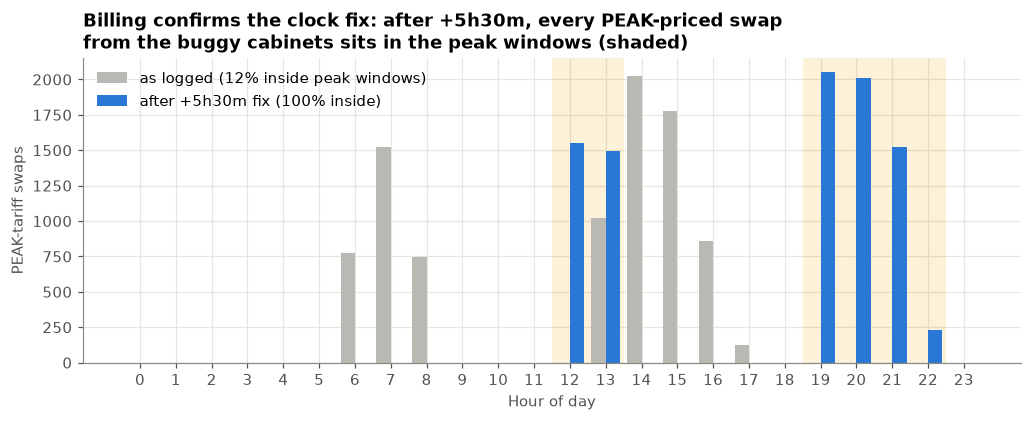

PEAK-tariff swaps in the bug window inside peak hours: 11.6% as logged → 100.0% after the fix (network-wide after cleaning: 100.0%)


In [5]:
fw = q("SELECT HOUR(raw_ts) h_logged, HOUR(ts) h_fixed, COUNT(*) n FROM sw WHERE ts <> raw_ts AND tariff_code='PEAK' GROUP BY ALL")
in_raw = 100 * fw[fw.h_logged.isin(PEAK_HOURS)].n.sum() / fw.n.sum(); in_fix = 100 * fw[fw.h_fixed.isin(PEAK_HOURS)].n.sum() / fw.n.sum()
net = q(f"SELECT 100*AVG((HOUR(ts) IN {tuple(PEAK_HOURS)})::INT) p FROM sw WHERE tariff_code='PEAK'").p[0]
keep("fw_peak_in_window_logged", in_raw); keep("fw_peak_in_window_fixed", in_fix); keep("peak_in_window_all", net)
lg = fw.groupby("h_logged").n.sum().reindex(range(24), fill_value=0); fx = fw.groupby("h_fixed").n.sum().reindex(range(24), fill_value=0)
fig, ax = plt.subplots(figsize=(11, 3.6))
for lo, hi in [(11.5, 13.5), (18.5, 22.5)]: ax.axvspan(lo, hi, color=YELLOW, alpha=0.15, lw=0)
ax.bar(np.arange(24) - 0.2, lg.values, width=0.4, color=GREY, label=f"as logged ({in_raw:.0f}% inside peak windows)")
ax.bar(np.arange(24) + 0.2, fx.values, width=0.4, color=BLUE, label=f"after +5h30m fix ({in_fix:.0f}% inside)")
ax.set_xticks(range(24)); ax.set_xlabel("Hour of day"); ax.set_ylabel("PEAK-tariff swaps"); ax.legend(loc="upper left")
ax.set_title("Billing confirms the clock fix: after +5h30m, every PEAK-priced swap from the buggy cabinets sits in the peak windows (shaded)")
save(fig, "a01_firmware_fix_validated")
print(f"PEAK-tariff swaps in the bug window inside peak hours: {in_raw:.1f}% as logged → {in_fix:.1f}% after the fix (network-wide after cleaning: {net:.1f}%)")

### 2.2 Near-duplicates: tested three stricter definitions
The brief says offline-sync retries create near-duplicates. If they existed, `offline_batch` rows would show more close repeats than `realtime` rows.

In [6]:
d1 = q('''WITH x AS (SELECT sync_mode, EPOCH(LEAD(ts) OVER (PARTITION BY rider_id, station_id ORDER BY ts) - ts) gap FROM sw)
          SELECT sync_mode, COUNT(*) n, SUM((gap<=180)::INT) hits FROM x GROUP BY 1''').set_index("sync_mode")
d2 = q('''WITH x AS (SELECT sync_mode, EPOCH(ts - LAG(ts) OVER (PARTITION BY rider_id, battery_in_id ORDER BY ts)) gap FROM sw WHERE battery_in_id IS NOT NULL)
          SELECT sync_mode, SUM((gap<=300)::INT) hits FROM x GROUP BY 1''').set_index("sync_mode")
d3 = q('''WITH x AS (SELECT sync_mode, EPOCH(raw_ts - LAG(raw_ts) OVER (PARTITION BY rider_id, station_id, battery_in_id, battery_out_id ORDER BY raw_ts)) gap FROM sw)
          SELECT sync_mode, SUM((gap<=600)::INT) hits FROM x GROUP BY 1''').set_index("sync_mode")
d4 = q('''SELECT sync_mode, SUM(c-1) hits FROM (SELECT sync_mode, rider_id, station_id, raw_ts, event_type, battery_in_id, battery_out_id, COUNT(*) c FROM sw GROUP BY ALL HAVING COUNT(*)>1) GROUP BY 1''').set_index("sync_mode")
dup = pd.DataFrame({
  "definition": ["Same rider + station, next attempt ≤ 3 min (main notebook)", "Same rider + same returned pack ≤ 5 min", "Same rider + station + both packs ≤ 10 min (raw time)", "Identical content, different event_id"],
  "offline_batch": [d1.hits.get("offline_batch", 0), d2.hits.get("offline_batch", 0), d3.hits.get("offline_batch", 0), d4.hits.get("offline_batch", 0) if len(d4) else 0],
  "realtime": [d1.hits.get("realtime", 0), d2.hits.get("realtime", 0), d3.hits.get("realtime", 0), d4.hits.get("realtime", 0) if len(d4) else 0]}).fillna(0)
dup["offline_batch"] = dup.offline_batch.astype(int); dup["realtime"] = dup.realtime.astype(int)
keep("dup_strict_offline", int(dup.offline_batch.iloc[1:].sum()))
display(dup.style.hide(axis="index"))
print(f"offline_batch rows: {d1.n.get('offline_batch', 0):,} of {d1.n.sum():,}")

definition,offline_batch,realtime
"Same rider + station, next attempt ≤ 3 min (main notebook)",971,5405
Same rider + same returned pack ≤ 5 min,0,6
Same rider + station + both packs ≤ 10 min (raw time),0,0
"Identical content, different event_id",0,0


offline_batch rows: 591,114 of 3,814,982


### 2.3 New anomalies found on re-check

In [7]:
a3w = q("SELECT COUNT(*) FILTER (WHERE slots_3w=0) no_slot, COUNT(*) n FROM sw WHERE vc='3W' AND done=1").iloc[0]
reuse = q('''WITH x AS (SELECT station_id, ts, LEAD(ts) OVER w nts, LEAD(station_id) OVER w nst FROM sw WHERE done=1 WINDOW w AS (PARTITION BY battery_out_id ORDER BY ts))
             SELECT 100*AVG((EPOCH(nts-ts)<3600 AND nst<>station_id)::INT) p FROM x''').p[0]
ret = q("SELECT COUNT(DISTINCT retired_date) n_dates, MIN(retired_date) d, COUNT(*) packs FROM raw_batteries WHERE retired_date IS NOT NULL").iloc[0]
after = q('''SELECT COUNT(*) swaps, COUNT(DISTINCT sw.battery_out_id) packs FROM sw JOIN raw_batteries b ON b.battery_id=sw.battery_out_id
             WHERE sw.done=1 AND b.retired_date IS NOT NULL AND sw.ts::DATE > b.retired_date''').iloc[0]
eol = q("SELECT MONTH(ts) mo, 100*AVG((soh_out<70)::INT) p FROM sw WHERE done=1 AND ts>='2025-04-01' GROUP BY 1 ORDER BY 1").set_index("mo").p
dec = q("SELECT station_id, decommissioned_date FROM stations WHERE decommissioned_date IS NOT NULL")
keep("anom_3w_no_slot_pct", 100*a3w.no_slot/a3w.n); keep("anom_pack_reissued_1h_pct", reuse); keep("anom_retired_swaps_after", int(after.swaps))
keep("anom_retired_packs_after", int(after.packs)); keep("eol_share_may25", eol.get(5, np.nan)); keep("eol_share_jun25", eol.get(6, np.nan))
anom = pd.DataFrame([
  ("3W swaps at stations with no 3W slots", f"{a3w.no_slot:,} of {a3w.n:,} completed 3W swaps ({100*a3w.no_slot/a3w.n:.0f}%) happen at stations listed with slots_3w = 0", "Treat slots_3w as unreliable; do not use it to explain 3W failures"),
  ("Pack IDs re-issued impossibly fast", f"{reuse:.1f}% of issued packs are issued again at a *different* station within 60 minutes", "Pack-level journeys are not physical; use pack IDs only for supplier/lot attributes"),
  ("Retirement is a ledger entry only", f"All {ret.packs:,} retirements share one date ({pd.Timestamp(ret.d).date()}); {after.packs:,} of those packs were still handed to riders afterwards ({after.swaps:,} swaps)", "Physically pull the packs; reconcile asset register with cabinet logs"),
  ("End-of-life packs in circulation", f"Packs below the 70% end-of-life line: {eol.get(4, 0):.1f}% of swaps in Apr 2025, {eol.get(5, 0):.1f}% in May, {eol.get(6, 0):.1f}% in Jun", "Add an SoH floor to the cabinet dispense logic"),
  ("Decommissioned station", ", ".join(f"{r.station_id} (closed {pd.Timestamp(r.decommissioned_date).date()})" for r in dec.itertuples()) or "none", "Negligible; no change"),
], columns=["anomaly", "evidence", "implication"])
anom.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"})

anomaly,evidence,implication
3W swaps at stations with no 3W slots,"212,621 of 372,264 completed 3W swaps (57%) happen at stations listed with slots_3w = 0",Treat slots_3w as unreliable; do not use it to explain 3W failures
Pack IDs re-issued impossibly fast,8.1% of issued packs are issued again at a *different* station within 60 minutes,Pack-level journeys are not physical; use pack IDs only for supplier/lot attributes
Retirement is a ledger entry only,"All 1,438 retirements share one date (2025-06-15); 1,438 of those packs were still handed to riders afterwards (33,761 swaps)",Physically pull the packs; reconcile asset register with cabinet logs
End-of-life packs in circulation,"Packs below the 70% end-of-life line: 1.5% of swaps in Apr 2025, 16.9% in May, 21.9% in Jun",Add an SoH floor to the cabinet dispense logic
Decommissioned station,STN-DEL-051 (closed 2025-05-20),Negligible; no change


### ✅ Finding: the cleaning decisions stand, and two new anomalies matter
- **Firmware fix proven by billing:** in the bug window, only **11.6%** of PEAK-priced swaps sit in peak hours as logged, and **100%** after the +5h30m shift. This is independent evidence from a different field than the hour-of-day curves.
- **No near-duplicates exist:** zero `offline_batch` duplicates under three stricter definitions (same rider + pack, same rider + station + both packs, identical content). Dropping nothing was right.
- **Retired packs are still in service:** all 1,438 retirements carry one date (15 Jun 2025), and every one of those packs was handed to riders afterwards (33,761 swaps). By June, **22% of swaps** issued a pack below the 70% end-of-life line. The retirement is on paper only.
- **Two fields to distrust:** `slots_3w` (57% of 3W swaps happen at stations listed with no 3W slots) and pack IDs (8% re-issued at a different station within an hour). We use pack IDs only for supplier/lot attributes, never for journeys.

## 3. Service failures: does the Gen1 × heat story survive?

### 3.1 The brief's premise: did failures really rise faster than swaps?

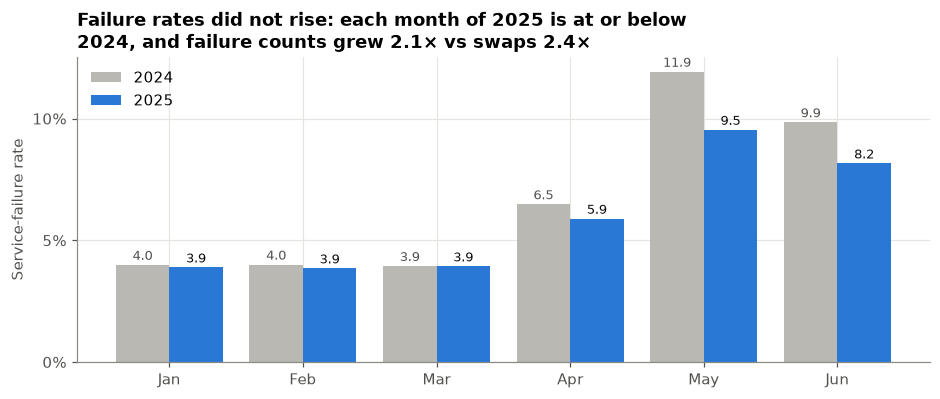

yr,2024,2025
mo,,
1,4.00,3.89
2,4.01,3.85
3,3.95,3.93
4,6.48,5.89
5,11.93,9.54
6,9.85,8.16


In [8]:
yoy = q("SELECT MONTH(ts) mo, YEAR(ts) yr, SUM(done) comp, SUM(fail) fails, 100*AVG(fail) rate FROM sw WHERE MONTH(ts)<=6 GROUP BY ALL ORDER BY 1,2")
p = yoy.pivot(index="mo", columns="yr", values=["rate", "fails", "comp"])
fail_x = p["fails"][2025].sum() / p["fails"][2024].sum(); comp_x = p["comp"][2025].sum() / p["comp"][2024].sum()
keep("h1_fail_count_growth_x", fail_x); keep("h1_completed_growth_x", comp_x); keep("months_2025_worse_than_2024", int((p["rate"][2025] > p["rate"][2024] + 0.05).sum()))
fig, ax = plt.subplots(figsize=(10, 3.6)); x = np.arange(6)
ax.bar(x - 0.2, p["rate"][2024], width=0.4, color=GREY, label="2024"); ax.bar(x + 0.2, p["rate"][2025], width=0.4, color=BLUE, label="2025")
for i in range(6):
    ax.text(i - 0.2, p["rate"][2024].iloc[i] + 0.2, f"{p['rate'][2024].iloc[i]:.1f}", ha="center", fontsize=8.5, color=INK2)
    ax.text(i + 0.2, p["rate"][2025].iloc[i] + 0.2, f"{p['rate'][2025].iloc[i]:.1f}", ha="center", fontsize=8.5, color=INK)
ax.set_xticks(x); ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun"]); pct_axis(ax); ax.set_ylabel("Service-failure rate"); ax.legend(loc="upper left")
ax.set_title(f"Failure rates did not rise: each month of 2025 is at or below 2024, and failure counts grew {fail_x:.1f}× vs swaps {comp_x:.1f}×")
save(fig, "a02_failures_yoy")
p["rate"].round(2)

### 3.2 "Top 20% of stations cause 43% of failures": exposure check
Ranking stations by *total* failures favours stations that were open longest and busiest.

In [9]:
st = q("SELECT station_id, gen, city, wave, COUNT(*) att, SUM(fail) fails, COUNT(DISTINCT DATE_TRUNC('month', ts)) n_mon FROM sw GROUP BY ALL")
st = st.sort_values("fails", ascending=False).reset_index(drop=True); k = int(0.2 * len(st)); top, rest = st.head(k), st.iloc[k:]
keep("top20_att_share", 100 * top.att.sum() / st.att.sum()); keep("top20_fail_share", 100 * top.fails.sum() / st.fails.sum())
keep("top20_concentration_x", METRICS["top20_fail_share"] / METRICS["top20_att_share"])
st["rate"] = 100 * st.fails / st.att; big = st[st.att > 5000].sort_values("rate", ascending=False); topr = big.head(int(0.2 * len(big)))
hot_gen1 = q(f"SELECT COUNT(*) n FROM stations WHERE charger_generation='Gen1' AND city IN {HOT}").n[0]
hot_share = q(f"SELECT 100*SUM(fail) FILTER (WHERE gen='Gen1' AND city IN {HOT})/SUM(fail) p FROM sw WHERE MONTH(ts) IN (4,5,6)").p[0]
hot_att = q(f"SELECT 100*AVG((gen='Gen1' AND city IN {HOT})::INT) p FROM sw WHERE MONTH(ts) IN (4,5,6)").p[0]
keep("hot_gen1_stations", int(hot_gen1)); keep("hot_gen1_summer_fail_share", hot_share); keep("hot_gen1_summer_att_share", hot_att)
keep("top20_by_rate_all_hot_gen1", bool(((topr.gen == "Gen1") & topr.city.isin(["Jaipur", "Delhi NCR", "Hyderabad"])).all()))
display(pd.DataFrame({"stations": [len(top), len(rest)], "share of attempts %": [METRICS["top20_att_share"], 100 - METRICS["top20_att_share"]],
                      "share of failures %": [METRICS["top20_fail_share"], 100 - METRICS["top20_fail_share"]], "avg months open": [top.n_mon.mean(), rest.n_mon.mean()]},
                     index=["top 20% by failure count", "other 80%"]).round(1))
print("Top 20% by failure RATE (stations with >5K attempts):"); display(topr.groupby(["gen", "city"]).size().rename("stations").to_frame())
print(f"The {hot_gen1} hot-city Gen1 stations handle {hot_att:.0f}% of summer attempts but cause {hot_share:.1f}% of summer failures")

,stations,share of attempts %,share of failures %,avg months open
top 20% by failure count,30,31.00,42.70,18.00
other 80%,120,69.00,57.30,12.50


Top 20% by failure RATE (stations with >5K attempts):


stations
gen  city               
Gen1 Delhi NCR        13
     Hyderabad         5
     Jaipur           10

The 36 hot-city Gen1 stations handle 32% of summer attempts but cause 57.5% of summer failures


### 3.3 Is Gen1 just busier? Failure rate at equal load
Hot-city station-days in summer, split into quartiles of attempts per charging slot.

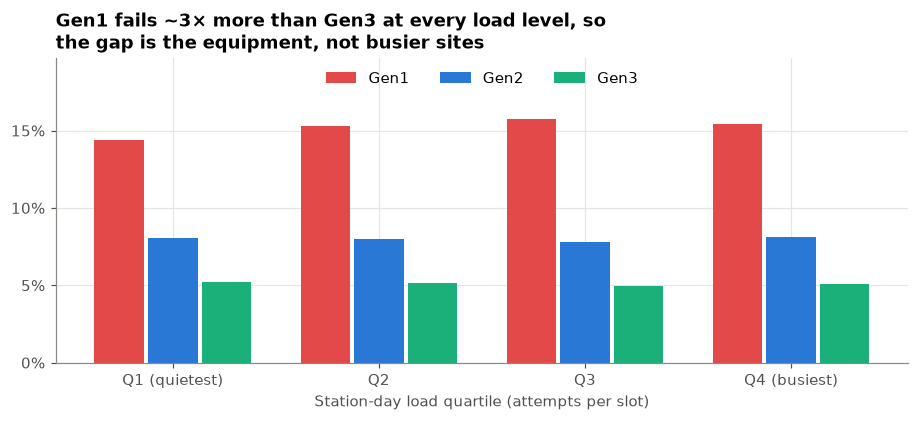

Summer load in hot cities, attempts per slot-day: Gen1 4.3, Gen3 6.1 (Gen3 is busier)


gen,Gen1,Gen2,Gen3
qt,,,
1,14.36,8.07,5.20
2,15.29,8.02,5.17
3,15.77,7.82,4.92
4,15.41,8.12,5.06


In [10]:
ld = q(f'''WITH d AS (SELECT station_id, gen, ts::DATE dy, ANY_VALUE(slots_2w + COALESCE(slots_3w,0)) slots, COUNT(*) n, SUM(fail) f FROM sw
                      WHERE MONTH(ts) IN (4,5,6) AND city IN {HOT} GROUP BY ALL),
          e AS (SELECT *, NTILE(4) OVER (ORDER BY n/slots, station_id, dy) qt FROM d)
          SELECT qt, gen, SUM(n) att, 100*SUM(f)/SUM(n) fail_rate, AVG(n/slots) att_per_slot FROM e GROUP BY ALL ORDER BY 1,2''')
lp = ld.pivot(index="qt", columns="gen", values="fail_rate")
keep("gen1_fail_min_quartile", lp["Gen1"].min()); keep("gen3_fail_max_quartile", lp["Gen3"].max())
lg = q(f'''SELECT gen, SUM(n)/SUM(nd*slots) att_per_slot_day FROM (SELECT station_id, gen, ANY_VALUE(slots_2w+COALESCE(slots_3w,0)) slots, COUNT(*) n, COUNT(DISTINCT ts::DATE) nd
           FROM sw WHERE MONTH(ts) IN (4,5,6) AND city IN {HOT} GROUP BY ALL) GROUP BY 1 ORDER BY 1''').set_index("gen").att_per_slot_day
keep("load_gen1", lg["Gen1"]); keep("load_gen3", lg["Gen3"])
fig, ax = plt.subplots(figsize=(10, 3.6)); x = np.arange(4)
for i, g in enumerate(["Gen1", "Gen2", "Gen3"]):
    ax.bar(x + (i - 1) * 0.26, lp[g], width=0.24, color=GCOL[g], label=g)
ax.set_xticks(x); ax.set_xticklabels(["Q1 (quietest)", "Q2", "Q3", "Q4 (busiest)"]); ax.set_xlabel("Station-day load quartile (attempts per slot)")
pct_axis(ax); ax.legend(ncol=3, loc="upper center"); ax.set_ylim(0, lp.values.max() * 1.25)
ax.set_title("Gen1 fails ~3× more than Gen3 at every load level, so the gap is the equipment, not busier sites")
save(fig, "a03_gen_by_load")
print(f"Summer load in hot cities, attempts per slot-day: Gen1 {lg['Gen1']:.1f}, Gen3 {lg['Gen3']:.1f} (Gen3 is busier)")
ld.pivot(index="qt", columns="gen", values="fail_rate").round(2)

### 3.4 Alternative mechanisms: outages, offline chargers, quarantined packs, hotter Gen1 cabinets?

In [11]:
alt = q('''SELECT gen, CASE WHEN MONTH(hour_start) IN (4,5,6) THEN 'summer' ELSE 'rest' END season, AVG(outage_minutes) outage_min_per_hour,
           100*AVG(chargers_online/slots) pct_chargers_online, AVG(packs_quarantined) packs_quarantined, AVG(cabinet_temp_c - ambient_temp_c) cabinet_minus_ambient_c,
           100*AVG((charged_2w_min=0)::INT) pct_hours_zero_stock
           FROM sh WHERE telemetry_status='ok' GROUP BY ALL ORDER BY 1,2''')
ob = q('''WITH hf AS (SELECT station_id, DATE_TRUNC('hour', ts) hr, COUNT(*) n, SUM(fail) f FROM sw GROUP BY ALL)
          SELECT CASE WHEN h.outage_minutes=0 THEN 'no outage' ELSE 'outage in hour' END hour_type, SUM(n) attempts, 100*SUM(f)/SUM(n) fail_rate
          FROM hf JOIN sh h ON h.station_id=hf.station_id AND h.hour_start=hf.hr GROUP BY 1''')
keep("outage_attempt_share", 100 * ob.set_index("hour_type").attempts.get("outage in hour", 0) / ob.attempts.sum())
display(alt.round(3)); ob.round(2)

,gen,season,outage_min_per_hour,pct_chargers_online,packs_quarantined,cabinet_minus_ambient_c,pct_hours_zero_stock
0,Gen1,rest,0.01,99.90,0.00,6.57,0.61
1,Gen1,summer,0.01,99.89,0.00,6.58,5.79
2,Gen2,rest,0.02,99.88,0.00,6.57,0.39
3,Gen2,summer,0.02,99.88,0.00,6.57,0.42
4,Gen3,rest,0.00,99.88,0.00,6.58,0.26
5,Gen3,summer,0.02,99.89,0.00,6.58,0.27


,hour_type,attempts,fail_rate
0,no outage,"3,814,243.00",5.55
1,outage in hour,739.00,6.09


### 3.5 Where exactly is the heat threshold, and what would cooling buy?
Gen1 telemetry at 1°C resolution. Failures lag the heat (cabinets drain during the hot afternoon and fail riders in the evening), so the failure link is measured per **station-day** against that day's peak cabinet temperature. The counterfactual asks: if every Gen1 hot-city summer day had peaked *d*°C cooler, what failure rate would it have had?

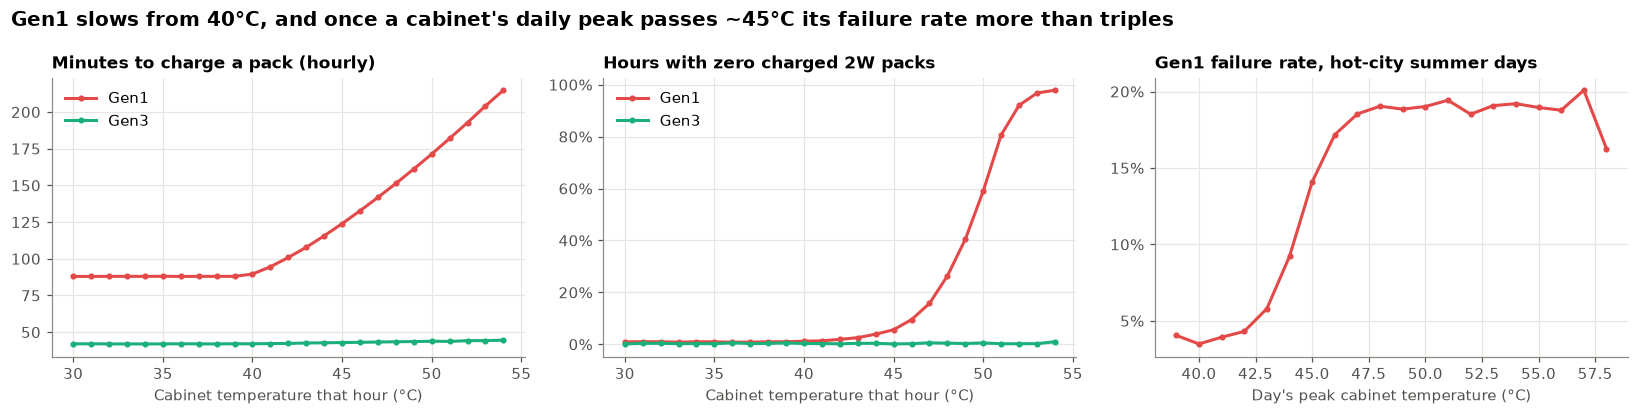

Gen3 replacement of the 36 hot-city Gen1 stations: ≈22,609 failures avoided per year


,cooling_c,failures_avoided_per_year,pct_of_gen3_replacement
0,2,"6,088.60",26.90
1,3,"9,138.70",40.40
2,5,"14,390.40",63.60


In [12]:
hb = q('''SELECT gen, FLOOR(cabinet_temp_c)::INT t, COUNT(*) n_hours, AVG(avg_charge_minutes) chg, 100*AVG((charged_2w_min=0)::INT) stockout
          FROM sh WHERE telemetry_status='ok' AND gen IN ('Gen1','Gen3') AND cabinet_temp_c BETWEEN 30 AND 54.99 GROUP BY ALL HAVING COUNT(*) >= 50 ORDER BY 1,2''')
g1 = hb[hb.gen == "Gen1"].set_index("t")
keep("gen1_chg_40c", g1.chg.get(40)); keep("gen1_chg_50c", g1.chg.get(50)); keep("gen1_stockout_45c", g1.stockout.get(45))
keep("gen1_stockout_48c", g1.stockout.get(48)); keep("gen1_stockout_50c", g1.stockout.get(50)); keep("gen1_stockout_52c", g1.stockout.get(52))
hf = q(f'''WITH a AS (SELECT station_id, ts::DATE dy, COUNT(*) n, SUM(fail) f FROM sw WHERE gen='Gen1' AND city IN {HOT} AND MONTH(ts) IN (4,5,6) GROUP BY ALL),
                t AS (SELECT station_id, hour_start::DATE dy, MAX(cabinet_temp_c) tmax FROM sh GROUP BY ALL)
           SELECT FLOOR(t.tmax)::INT t, SUM(a.n) n, SUM(a.f) f FROM a JOIN t USING(station_id, dy) WHERE t.tmax IS NOT NULL GROUP BY 1 ORDER BY 1''')
hf = hf[hf.n >= 500].reset_index(drop=True); rate = hf.f / hf.n
keep("gen1_day_fail_below43", 100 * hf[hf.t < 43].f.sum() / hf[hf.t < 43].n.sum()); keep("gen1_day_fail_46plus", 100 * hf[hf.t >= 46].f.sum() / hf[hf.t >= 46].n.sum())
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col, ttl in [(axes[0], "chg", "Minutes to charge a pack (hourly)"), (axes[1], "stockout", "Hours with zero charged 2W packs")]:
    for g in ["Gen1", "Gen3"]:
        d = hb[hb.gen == g]; ax.plot(d.t, d[col], color=GCOL[g], marker="o", ms=3, label=g)
    ax.set_xlabel("Cabinet temperature that hour (°C)"); ax.set_title(ttl, fontsize=11); ax.legend(loc="upper left")
pct_axis(axes[1])
axes[2].plot(hf.t, 100 * rate, color=RED, marker="o", ms=3); axes[2].set_xlabel("Day's peak cabinet temperature (°C)"); pct_axis(axes[2])
axes[2].set_title("Gen1 failure rate, hot-city summer days", fontsize=11)
fig.suptitle("Gen1 slows from 40°C, and once a cabinet's daily peak passes ~45°C its failure rate more than triples", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(); save(fig, "a04_heat_threshold")

tot = q(f"SELECT COUNT(*) n, SUM(fail) f FROM sw WHERE gen='Gen1' AND city IN {HOT} AND MONTH(ts) IN (4,5,6)").iloc[0]
scale = tot.n / hf.n.sum()
g = q(f"SELECT city, gen, COUNT(*) att, AVG(fail) f FROM sw WHERE MONTH(ts) IN (4,5,6) AND city IN {HOT} GROUP BY ALL").pivot(index="city", columns="gen", values=["att", "f"])
gen3_avoid = float(((g["f"]["Gen1"] - g["f"]["Gen3"]) * g["att"]["Gen1"]).sum() / 2)
keep("gen3_replacement_fails_avoided_per_year", gen3_avoid)
rows = []
for d in [2, 3, 5]:
    cf = (hf.n * np.interp(hf.t - d, hf.t, rate)).sum()
    avoided = (hf.f.sum() - cf) * scale / 2
    rows.append(dict(cooling_c=d, failures_avoided_per_year=avoided, pct_of_gen3_replacement=100 * avoided / gen3_avoid))
    keep(f"cooling_{d}c_fails_avoided", avoided); keep(f"cooling_{d}c_pct_of_gen3", 100 * avoided / gen3_avoid)
print(f"Gen3 replacement of the {hot_gen1} hot-city Gen1 stations: ≈{gen3_avoid:,.0f} failures avoided per year")
pd.DataFrame(rows).round(1)

### 3.6 3W riders: is it really about 3W slots?

In [13]:
w3 = q('''SELECT CASE WHEN slots_3w>0 THEN 'station has 3W slots' ELSE 'station lists 0 3W slots' END station, CASE WHEN MONTH(ts) IN (4,5,6) THEN 'summer' ELSE 'rest of year' END season,
          COUNT(*) attempts, 100*AVG(fail) fail_rate FROM sw WHERE vc='3W' GROUP BY ALL ORDER BY 1,2''')
v = q('''SELECT vc, 100*AVG(fail) FILTER (WHERE MONTH(ts) NOT IN (4,5,6)) rest_of_year, 100*AVG(fail) FILTER (WHERE MONTH(ts) IN (4,5,6)) summer,
         100*AVG((event_type='failed_no_charged_battery')::INT) FILTER (WHERE MONTH(ts) NOT IN (4,5,6)) no_battery_rest FROM sw GROUP BY 1 ORDER BY 1''').set_index("vc")
keep("fail_3w_rest", v.loc["3W", "rest_of_year"]); keep("fail_2w_rest", v.loc["2W", "rest_of_year"])
display(w3.pivot(index="station", columns="season", values="fail_rate").round(2)); v.round(2)

season,rest of year,summer
station,,
station has 3W slots,8.63,12.22
station lists 0 3W slots,8.61,12.24


,rest_of_year,summer,no_battery_rest
vc,,,
2W,3.34,7.93,1.97
3W,8.62,12.23,5.47


### 3.7 What is a failure worth? Do riders retry?
If a failed rider simply came back an hour later, a failure would cost experience but not revenue.

In [14]:
rt = q('''WITH x AS (SELECT fail, done, ts, LEAD(ts) OVER w nts, LEAD(done) OVER w ndone FROM sw WINDOW w AS (PARTITION BY rider_id ORDER BY ts))
          SELECT CASE WHEN fail=1 THEN 'after a failed attempt' ELSE 'after a completed swap' END after_event, COUNT(*) n,
                 100*AVG((ndone=1 AND EPOCH(nts-ts)<=3600)::INT) pct_completed_within_1h, MEDIAN(EPOCH(nts-ts)/3600) median_hours_to_next
          FROM x WHERE fail=1 OR done=1 GROUP BY 1''').set_index("after_event")
lost = q("SELECT vc, SUM(fail) fails, AVG(rev) FILTER (WHERE done=1) arps FROM sw GROUP BY 1")
lost_m = (lost.fails * lost.arps).sum() / 1e6
arps_hot = q(f"SELECT AVG(rev) a FROM sw WHERE done=1 AND gen='Gen1' AND city IN {HOT}").a[0]
keep("retry_within_1h_pct", rt.loc["after a failed attempt", "pct_completed_within_1h"]); keep("failure_revenue_lost_m_18mo", lost_m)
keep("gen3_replacement_revenue_m_per_year", gen3_avoid * arps_hot / 1e6)
print(f"Revenue not collected on failed attempts over 18 months: ≈₹{lost_m:.1f}M | Gen1→Gen3 in hot cities recovers ≈₹{METRICS['gen3_replacement_revenue_m_per_year']:.1f}M a year")
rt.round(2)

Revenue not collected on failed attempts over 18 months: ≈₹14.3M | Gen1→Gen3 in hot cities recovers ≈₹1.4M a year


,n,pct_completed_within_1h,median_hours_to_next
after_event,,,
after a failed attempt,211849,4.55,21.52
after a completed swap,3586675,4.56,21.53


### ✅ Finding: the Gen1 × heat story survives every test we threw at it
- **Not a load artefact:** in hot cities in summer, Gen1 fails **14–16% in every load quartile** vs 5% for Gen3, and Gen3 sites are *busier* (6.1 vs 4.3 attempts per slot-day). Outages touch 0.02% of attempts, chargers are online 99.9% of the time, and all generations run 6.6°C above ambient. The difference is how Gen1 charges when hot.
- **The threshold:** Gen1 charge time is flat at 88 min up to 40°C, then climbs (124 min at 45°C, 171 at 50°C). Failures are low (**4.1%**) on days whose cabinet peak stays under 43°C and **18.7%** once it passes 46°C.
- **Reframe the concentration stat:** the "worst 20% = 43% of failures" stations were open all 18 months and carry 31% of attempts, so it is only a 1.4× concentration. The sharper fact: **36 hot-city Gen1 stations handle 32% of summer attempts but cause 57.5% of summer failures**, and every station in the top 20% by failure *rate* is one of them.
- **Premise of the brief:** failures did **not** rise faster than swaps. H1-2025 failure counts grew 2.1× while completed swaps grew 2.4×, and no month of 2025 was worse than the same month of 2024. The problem is seasonal and has not worsened, but it has not been fixed either.
- **3W:** the 3W gap is year-round (8.6% vs 3.3% outside summer) and does not depend on 3W slots. We drop the "fewer 3W slots" explanation and flag 3W stock as a separate, unexplained issue.
- **Failures cost revenue:** a failure never triggers a retry (the next attempt comes at the same time as after a successful swap), so each one is a lost swap: **≈₹14.3M over 18 months**. Gen1→Gen3 in the hot cities recovers **≈₹1.4M a year** in revenue, before any churn benefit.
- **A cheaper first step:** cooling Gen1 cabinets by 2°C, 3°C or 5°C would avoid about 6.1K, 9.1K or 14.4K failures a year: **27%, 40% or 64%** of what full Gen3 replacement delivers (22.6K).

## 4. Batteries: is it Kyron, or three Kyron lots?

### 4.1 Degradation by manufacturing lot

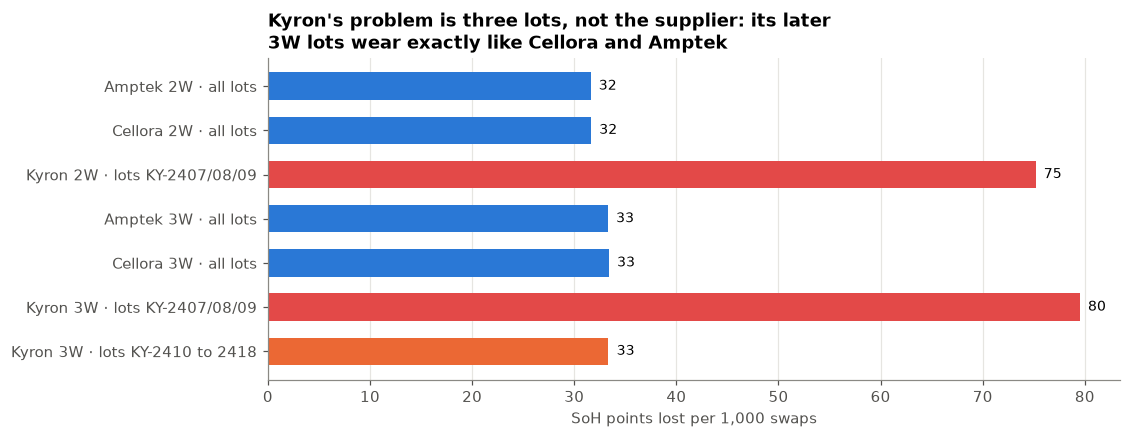

,supplier,pack_type,lots,packs,soh_loss_per_1k_swaps,wear_inr_per_swap,retired,first_commissioned
0,Amptek,2W_2.1kWh,all lots,1098,31.60,34.60,0.00,2024-03-01
1,Cellora,2W_2.1kWh,all lots,3035,31.60,34.70,0.00,2023-03-01
2,Kyron,2W_2.1kWh,lots KY-2407/08/09,1385,75.20,82.30,"1,385.00",2024-09-10
3,Amptek,3W_4.8kWh,all lots,209,33.30,77.50,0.00,2024-03-01
4,Cellora,3W_4.8kWh,all lots,520,33.40,77.90,0.00,2023-03-01
5,Kyron,3W_4.8kWh,lots KY-2407/08/09,76,79.50,186.00,53.00,2024-07-01
6,Kyron,3W_4.8kWh,lots KY-2410 to 2418,177,33.40,77.50,0.00,2024-10-02


In [15]:
lotw = q(f'''SELECT supplier, pack_type, CASE WHEN supplier<>'Kyron' THEN 'all lots' WHEN manufacturing_lot IN {BAD_LOTS} THEN 'lots KY-2407/08/09' ELSE 'lots KY-2410 to 2418' END lots,
             COUNT(*) packs, 1000*AVG(soh_loss_per_swap) soh_loss_per_1k_swaps, MEDIAN(wear_inr_per_swap) wear_inr_per_swap,
             SUM((retired_date IS NOT NULL)::INT) retired, MIN(commission_date)::DATE first_commissioned FROM bat_wear GROUP BY ALL ORDER BY 2,1,3''')
lw = lotw.set_index(["supplier", "pack_type", "lots"])
keep("kyron_2w_bad_loss_1k", lw.loc[("Kyron", "2W_2.1kWh", "lots KY-2407/08/09"), "soh_loss_per_1k_swaps"])
keep("kyron_3w_bad_loss_1k", lw.loc[("Kyron", "3W_4.8kWh", "lots KY-2407/08/09"), "soh_loss_per_1k_swaps"])
keep("kyron_3w_later_loss_1k", lw.loc[("Kyron", "3W_4.8kWh", "lots KY-2410 to 2418"), "soh_loss_per_1k_swaps"])
keep("cellora_3w_loss_1k", lw.loc[("Cellora", "3W_4.8kWh", "all lots"), "soh_loss_per_1k_swaps"]); keep("cellora_2w_loss_1k", lw.loc[("Cellora", "2W_2.1kWh", "all lots"), "soh_loss_per_1k_swaps"])
keep("kyron_later_lot_packs", int(lw.loc[("Kyron", "3W_4.8kWh", "lots KY-2410 to 2418"), "packs"]))
d = lotw.assign(label=lotw.supplier + " " + lotw.pack_type.str[:2] + " · " + lotw.lots).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.barh(d.label, d.soh_loss_per_1k_swaps, color=[RED if "2407" in l else (ORANGE if "2410" in l else BLUE) for l in d.lots], height=0.62)
for i, v in enumerate(d.soh_loss_per_1k_swaps): ax.text(v + 0.8, i, f"{v:.0f}", va="center", fontsize=9)
ax.set_xlabel("SoH points lost per 1,000 swaps"); ax.grid(axis="y", visible=False)
ax.set_title("Kyron's problem is three lots, not the supplier: its later 3W lots wear exactly like Cellora and Amptek")
save(fig, "a05_wear_by_lot")
lotw.round(1)

### 4.2 Could heat, city or swap timing explain Kyron's numbers?

In [16]:
kc = q('''SELECT city, 100*AVG((sup_out='Kyron')::INT) FILTER (WHERE ts>='2024-10-01') kyron_share_of_2w_packs_issued,
          AVG(soh_out) FILTER (WHERE sup_out='Kyron' AND ts>='2025-06-01') kyron_soh_jun25, AVG(soh_out) FILTER (WHERE sup_out<>'Kyron' AND ts>='2025-06-01') other_soh_jun25
          FROM sw WHERE done=1 AND vc='2W' GROUP BY 1 ORDER BY 2 DESC''')
keep("kyron_share_hot_cities", kc[kc.city.isin(["Jaipur", "Delhi NCR", "Hyderabad"])].kyron_share_of_2w_packs_issued.mean())
keep("kyron_share_mild_cities", kc[~kc.city.isin(["Jaipur", "Delhi NCR", "Hyderabad"])].kyron_share_of_2w_packs_issued.mean())
keep("kyron_soh_city_spread", kc.kyron_soh_jun25.max() - kc.kyron_soh_jun25.min())
display(kc.round(2))
tm = q('''SELECT sup_in supplier, AVG(soc_in) soc_when_returned, AVG(km) km_per_swap, AVG(km/NULLIF(100-soc_in,0)) km_per_soc_point
          FROM sw WHERE done=1 AND pack_in LIKE '2W%' AND km IS NOT NULL AND soc_in < 95 GROUP BY 1 ORDER BY 1''')
tm.round(3)

,city,kyron_share_of_2w_packs_issued,kyron_soh_jun25,other_soh_jun25
0,Delhi NCR,39.42,62.99,80.73
1,Hyderabad,39.29,63.01,80.74
2,Jaipur,38.74,63.00,80.72
3,Pune,8.53,62.98,80.73
4,Bengaluru,8.49,62.97,80.73
5,Mumbai,8.39,62.99,80.73


,supplier,soc_when_returned,km_per_swap,km_per_soc_point
0,Amptek,9.27,60.87,0.67
1,Cellora,9.27,60.87,0.67
2,Kyron,9.24,48.63,0.54


### 4.3 At the same SoH reading, does a Kyron pack deliver the same range?

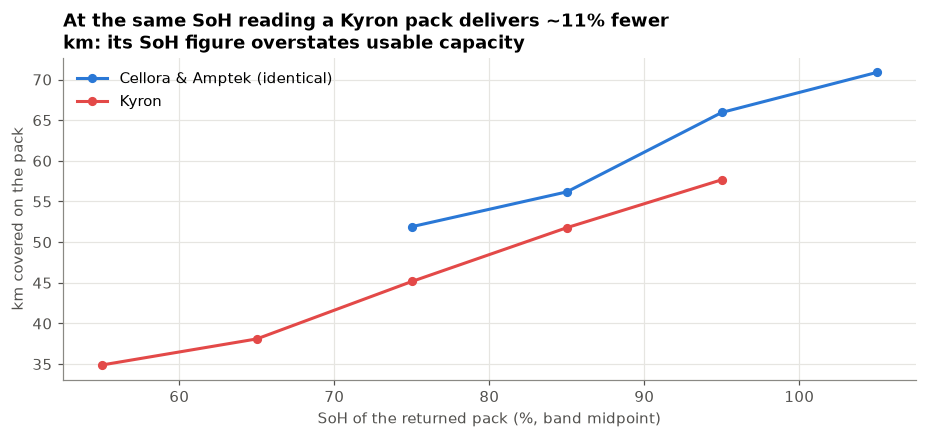

supplier,Amptek,Cellora,Kyron
soh_band,,,
50.00,NaN,NaN,34.90
60.00,NaN,NaN,38.10
70.00,51.90,51.90,45.20
80.00,56.20,56.20,51.80
90.00,66.00,66.00,57.70
100.00,NaN,70.90,NaN


In [17]:
kb = q('''SELECT FLOOR(soh_in/10)*10 soh_band, sup_in supplier, AVG(km) km, COUNT(*) n FROM sw WHERE done=1 AND pack_in LIKE '2W%' AND km IS NOT NULL
          GROUP BY ALL HAVING COUNT(*) > 2000 ORDER BY 1''').pivot(index="soh_band", columns="supplier", values="km")
both = kb.dropna(); gap = 100 * (1 - both["Kyron"] / both[["Cellora", "Amptek"]].mean(axis=1))
keep("kyron_km_gap_same_soh_pct", gap.mean())
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(kb.index + 5, kb[["Cellora", "Amptek"]].mean(axis=1), color=BLUE, marker="o", ms=5, label="Cellora & Amptek (identical)")
ax.plot(kb.index + 5, kb["Kyron"], color=RED, marker="o", ms=5, label="Kyron")
ax.set_xlabel("SoH of the returned pack (%, band midpoint)"); ax.set_ylabel("km covered on the pack"); ax.legend()
ax.set_title(f"At the same SoH reading a Kyron pack delivers ~{gap.mean():.0f}% fewer km: its SoH figure overstates usable capacity")
save(fig, "a06_km_at_same_soh")
kb.round(1)

### 4.4 The money: write-off vs excess wear (one cost, not two), and what is still outstanding

In [18]:
normal = lotw[lotw.supplier != "Kyron"].groupby("pack_type").soh_loss_per_1k_swaps.mean()
bad = q(f"SELECT pack_type, COUNT(*) packs, SUM(purchase_cost_inr) cost_inr FROM raw_batteries WHERE supplier='Kyron' AND manufacturing_lot IN {BAD_LOTS} GROUP BY 1").set_index("pack_type")
badrate = lotw[lotw.lots == "lots KY-2407/08/09"].set_index("pack_type").soh_loss_per_1k_swaps
econ = sum(bad.loc[pk, "cost_inr"] * (1 - normal[pk] / badrate[pk]) for pk in bad.index)
wo = q("SELECT pack_type, COUNT(*) packs, SUM(purchase_cost_inr) cost_inr FROM raw_batteries WHERE retired_date IS NOT NULL GROUP BY 1").set_index("pack_type")
ky = q("SELECT pack_in, COUNT(*) n FROM swc WHERE sup_in='Kyron' AND ts >= '2024-07-01' GROUP BY 1").set_index("pack_in").n
wrate = q("SELECT supplier, pack_type, w FROM wear_rate").set_index(["supplier", "pack_type"]).w
excess_wear = sum(ky.get(pk, 0) * (wrate[("Kyron", pk)] - wrate[("Cellora", pk)]) for pk in ["2W_2.1kWh", "3W_4.8kWh"]) / 1e6
fleet2w = q("SELECT COUNT(*) n FROM raw_batteries WHERE pack_type='2W_2.1kWh'").n[0]
keep("writeoff_all_m", wo.cost_inr.sum() / 1e6); keep("writeoff_2w_m", wo.loc["2W_2.1kWh", "cost_inr"] / 1e6); keep("writeoff_2w_packs", int(wo.loc["2W_2.1kWh", "packs"]))
keep("kyron_premature_loss_m", econ / 1e6); keep("kyron_excess_wear_m_per_year", excess_wear)
keep("retired_2w_share_of_fleet", 100 * wo.loc["2W_2.1kWh", "packs"] / fleet2w)
money = pd.DataFrame([
  ("Purchase cost of all retired packs (1,438)", METRICS["writeoff_all_m"], "gross; these packs gave 7–9 months of service"),
  ("…of which 2W packs", METRICS["writeoff_2w_m"], "the figure to quote next to '1,385 2W packs'"),
  ("Premature part of that cost (vs a normal-lot pack)", METRICS["kyron_premature_loss_m"], "the economic loss from the bad lots"),
  ("Excess wear, Jul-24 → Jun-25 (main notebook method)", METRICS["kyron_excess_wear_m_per_year"], "SAME money as the line above, spread per swap: never add them"),
  ("Replacement packs needed (2W)", METRICS["writeoff_2w_m"], f"{METRICS['retired_2w_share_of_fleet']:.0f}% of the 2W fleet must be replaced before the next summer"),
], columns=["item", "₹M", "how to read it"])
money.round(1).style.hide(axis="index").set_properties(**{"text-align": "left"})

item,₹M,how to read it
"Purchase cost of all retired packs (1,438)",47.900000,gross; these packs gave 7–9 months of service
…of which 2W packs,44.300000,"the figure to quote next to '1,385 2W packs'"
Premature part of that cost (vs a normal-lot pack),28.700000,the economic loss from the bad lots
"Excess wear, Jul-24 → Jun-25 (main notebook method)",34.000000,"SAME money as the line above, spread per swap: never add them"
Replacement packs needed (2W),44.300000,25% of the 2W fleet must be replaced before the next summer


### ⚠️ Finding: a lot problem, not a supplier problem, and the money was double counted
- **Three lots, not Kyron:** KY-2407/08/09 lose 75 (2W) and 80 (3W) SoH points per 1,000 swaps. Kyron's later 3W lots (KY-2410 to 2418, 177 packs) lose **33**, identical to Cellora and Amptek. Kyron made no 2W packs after the bad lots, so there is no evidence either way on its current 2W quality.
- **Not heat, not usage:** Kyron packs were concentrated in the hot cities (39% of 2W packs issued vs 8.5% in mild cities). Yet their SoH is identical in all six cities, and riders return every supplier's packs at the same ~9% charge. The degradation is in the cells.
- **Kyron's SoH reading flatters it:** at the same SoH band a Kyron pack delivers **~11% fewer km**. An SoH-based routing rule would let weak Kyron packs through.
- **The money:** the ₹47.9M figure is the gross purchase cost of *all* 1,438 retired packs (₹44.3M for the 1,385 2W packs), which had already given 7–9 months of service. The **premature** part of that cost is ≈₹28.7M. The ₹34.0M of 'excess wear' is the same money spread per swap, so the two must never be added. Once the packs are physically pulled, there is no recurring saving to claim.
- **The real forward cost:** the retired 2W packs are **25% of the 2W fleet**. Replacing them (≈₹44M) before next summer is what the 'more batteries' budget line should fund.

## 5. Margin: how much of the erosion is structural?

### 5.1 The '+₹3.4 energy' step in the margin bridge

In [19]:
en = q('''SELECT CASE WHEN ts<'2024-07-01' THEN '1 H1-2024' WHEN ts<'2025-01-01' THEN '2 H2-2024' ELSE '3 H1-2025' END period, AVG(kwh) kwh_per_swap,
          AVG(soh_in) avg_soh_returned, AVG(soc_in) avg_soc_returned, AVG(grid_tariff) tariff_inr_kwh FROM sw WHERE done=1 AND pack_in LIKE '2W%' GROUP BY 1 ORDER BY 1''')
eb = q("SELECT FLOOR(soh_in/10)*10 soh_band, AVG(kwh) kwh_per_swap, COUNT(*) n FROM sw WHERE done=1 AND pack_in LIKE '2W%' GROUP BY 1 HAVING COUNT(*)>2000 ORDER BY 1")
keep("kwh_2w_h1_24", en.kwh_per_swap.iloc[0]); keep("kwh_2w_h1_25", en.kwh_per_swap.iloc[2]); keep("soh_2w_h1_24", en.avg_soh_returned.iloc[0]); keep("soh_2w_h1_25", en.avg_soh_returned.iloc[2])
display(en.round(3)); eb.round(3)

,period,kwh_per_swap,avg_soh_returned,avg_soc_returned,tariff_inr_kwh
0,1 H1-2024,2.02,96.84,9.32,9.31
1,2 H2-2024,1.91,91.67,9.26,9.30
2,3 H1-2025,1.69,81.25,9.25,9.32


,soh_band,kwh_per_swap,n
0,50.00,1.51,6828
1,60.00,1.55,144844
2,70.00,1.66,224730
3,80.00,1.74,1438247
4,90.00,1.97,1395793
5,100.00,2.06,3969


### 5.2 Margin per swap with and without the three bad lots

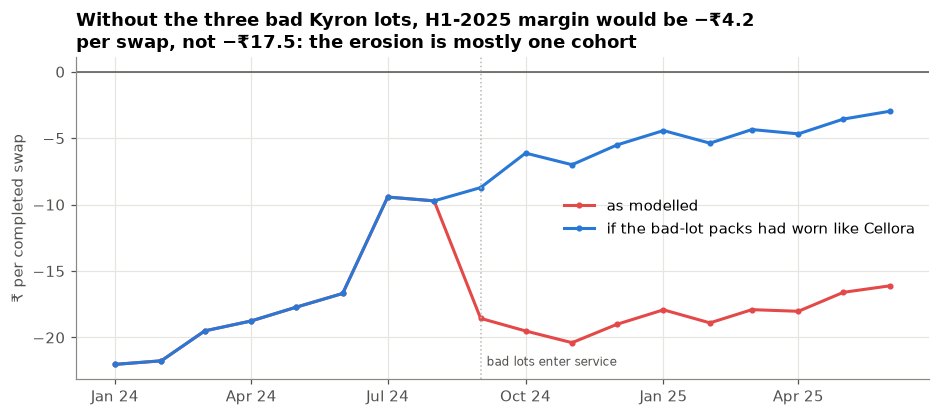

In [20]:
cell2w = float(q("SELECT w FROM wear_rate WHERE supplier='Cellora' AND pack_type='2W_2.1kWh'").w[0])
cmm = q(f'''SELECT DATE_TRUNC('month', ts) m, AVG(cm) cm_actual,
            AVG(cm + CASE WHEN sup_in='Kyron' AND pack_in LIKE '2W%' THEN wear_cost - {cell2w} ELSE 0 END) cm_without_bad_lots,
            AVG(rev - energy_cost - fixed_cost) cm_before_wear FROM swc GROUP BY 1 ORDER BY 1''')
cmm["m"] = pd.to_datetime(cmm.m)
h = q(f'''SELECT AVG(cm) a, AVG(cm + CASE WHEN sup_in='Kyron' AND pack_in LIKE '2W%' THEN wear_cost - {cell2w} ELSE 0 END) b FROM swc WHERE ts >= '2025-01-01' ''').iloc[0]
keep("cm_h1_25_actual", h.a); keep("cm_h1_25_without_bad_lots", h.b); keep("cm_gap_share_from_bad_lots", 100 * (h.b - h.a) / -h.a)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(cmm.m, cmm.cm_actual, color=RED, marker="o", ms=3, label="as modelled"); ax.plot(cmm.m, cmm.cm_without_bad_lots, color=BLUE, marker="o", ms=3, label="if the bad-lot packs had worn like Cellora")
ax.axhline(0, color=INK2, lw=1); ax.axvline(pd.Timestamp("2024-09-01"), color=GREY, ls=":", lw=1); ax.text(pd.Timestamp("2024-09-05"), ax.get_ylim()[0] + 1, "bad lots enter service", fontsize=8, color=INK2)
ax.set_ylabel("₹ per completed swap"); date_axis(ax); ax.legend(loc="center right")
ax.set_title(f"Without the three bad Kyron lots, H1-2025 margin would be {inr(h.b)} per swap, not {inr(h.a)}: the erosion is mostly one cohort")
save(fig, "a07_cm_without_bad_lots")

### 5.3 Partner margins: fully loaded vs variable (before site costs)
For a decision about one partner, site rent is sunk; what matters is whether a swap covers its own energy and battery wear.

In [21]:
pm = q('''SELECT COALESCE(p.partner_name,'Independent') partner, COALESCE(p.vehicle_class, 'mixed') vcl, COUNT(*) swaps, AVG(rev) rev_per_swap,
          AVG(cm) cm_fully_loaded, AVG(rev - energy_cost - wear_cost) variable_margin, AVG(rev - energy_cost) before_wear, AVG(wear_cost) wear
          FROM swc LEFT JOIN raw_fleet_partners p USING(partner_id) WHERE ts >= '2025-01-01' GROUP BY ALL ORDER BY swaps DESC''')
keep("zipdrop_variable_margin", pm.set_index("partner").loc["ZipDrop", "variable_margin"]); keep("indep_variable_margin", pm.set_index("partner").loc["Independent", "variable_margin"])
keep("partners_negative_variable", int((pm[pm.partner != "Independent"].variable_margin < 0).sum()))
zq = q('''SELECT DATE_TRUNC('quarter', ts) qtr, 100*SUM(done) FILTER (WHERE partner_id='FP-03')/SUM(done) zipdrop_share_pct FROM sw GROUP BY 1 ORDER BY 1''')
zs = q('''SELECT (ts >= '2024-11-01') after_deal, 100*SUM(done) FILTER (WHERE partner_id='FP-03')/SUM(done) zd_share FROM sw GROUP BY 1''').set_index("after_deal").zd_share
keep("zipdrop_share_before", zs.loc[False]); keep("zipdrop_share_after", zs.loc[True])
display(pm.round(2)); zq.assign(qtr=pd.to_datetime(zq.qtr).dt.to_period("Q").astype(str)).round(2)

,partner,vcl,swaps,rev_per_swap,cm_fully_loaded,variable_margin,before_wear,wear
0,Independent,mixed,581013,70.10,-9.73,2.05,53.25,51.19
1,ZipDrop,2W,262396,48.64,-31.05,-19.92,30.84,50.77
2,FeastFly,2W,245889,63.98,-15.58,-3.94,47.10,51.03
3,ParcelNest,2W,137592,57.53,-22.53,-10.74,40.65,51.39
4,Swiggle Go,2W,111004,60.31,-19.56,-7.77,43.23,51.01
5,CargoTuk,3W,62042,101.38,-27.93,-16.04,62.44,78.49
6,QuickCart,2W,58755,64.26,-14.80,-3.10,47.55,50.65
7,RideMitra,2W,58741,64.09,-15.92,-3.47,47.31,50.78
8,DabbaXpress,2W,44433,65.46,-13.77,-2.13,48.81,50.94
9,MetroMove,mixed,40313,59.59,-20.78,-8.95,42.72,51.67


,qtr,zipdrop_share_pct
0,2024Q1,15.14
1,2024Q2,14.80
2,2024Q3,15.14
3,2024Q4,15.55
4,2025Q1,15.70
5,2025Q2,15.17


### ➕ Finding: most of the margin erosion is one cohort, and ZipDrop is worse than we said
- **Energy step is a symptom:** kWh per 2W swap fell from 2.02 to 1.69 as average returned SoH fell from 96.8% to 81.2%. The '+₹3.4 energy' in the margin bridge is riders receiving less energy per swap, not an efficiency gain.
- **Margin without the bad lots:** if the bad-lot packs had worn like Cellora, H1-2025 margin would be **−₹4.2 per swap instead of −₹17.5**. About **76%** of the loss is the bad lots, so the structural margin problem is much smaller than the headline suggests.
- **Partners on a variable basis:** before any site costs, independents earn **+₹2.1 per swap**, while **all 12 fleet partners are negative**. ZipDrop is worst at **−₹19.9**, so it destroys value even on the most generous accounting.
- **The ZipDrop discount bought nothing:** ZipDrop's share of swaps was 15.1% before the 28% amendment and 15.5% after.

## 6. Pricing pilot: did riders react?
The main notebook measured revenue **per swap**. A rollout sizing also needs to know whether riders swapped **less often**. Here: independent rider-months (riders active ≥3 months, Jul 2024 – Mar 2025), rider and month fixed effects, SEs clustered by rider.

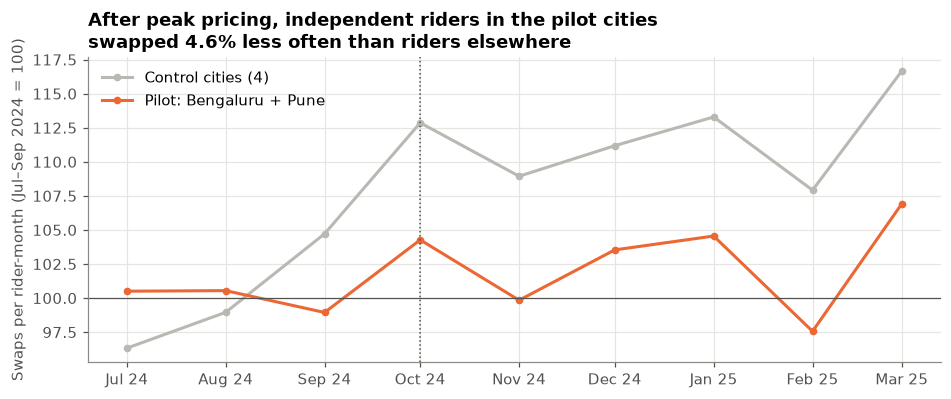

Revenue per swap +11.8% but revenue per rider-month only +7.9% → rollout ≈ ₹3.7M a year, not ₹6.1M


,effect,ci_low,ci_high,p,pre_mean_pilot,pct
swaps,-0.98,-1.36,-0.61,0.00,21.60,-4.56
revenue,115.40,89.73,141.06,0.00,"1,456.20",7.92


In [22]:
rm = q('''SELECT rider_id, DATE_TRUNC('month', ts)::VARCHAR m, MAX((city IN ('Bengaluru','Pune'))::INT) pilot, (MIN(ts) >= '2024-10-01')::INT post,
          COUNT(*) FILTER (WHERE done=1) swaps, SUM(rev) revenue FROM sw WHERE partner_id IS NULL AND ts >= '2024-07-01' AND ts < '2025-04-01' GROUP BY rider_id, DATE_TRUNC('month', ts)''')
rm = rm[rm.groupby("rider_id").m.transform("count") >= 3].copy()
rm["tr"] = rm.pilot * rm.post
res = {}
for y in ["swaps", "revenue"]:
    d = rm.assign(y_dm=rm[y] - rm.groupby("rider_id")[y].transform("mean"), tr_dm=rm.tr - rm.groupby("rider_id").tr.transform("mean"))
    f = smf.ols("y_dm ~ tr_dm + C(m)", data=d).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(d.rider_id)[0]})
    base = rm[(rm.pilot == 1) & (rm.post == 0)][y].mean()
    res[y] = dict(effect=f.params["tr_dm"], ci_low=f.conf_int().loc["tr_dm", 0], ci_high=f.conf_int().loc["tr_dm", 1], p=f.pvalues["tr_dm"], pre_mean_pilot=base, pct=100 * f.params["tr_dm"] / base)
res = pd.DataFrame(res).T
keep("did_swaps_per_rider_month", res.loc["swaps", "effect"]); keep("did_swaps_pct", res.loc["swaps", "pct"])
keep("did_rev_per_rider_month", res.loc["revenue", "effect"]); keep("did_rev_per_rider_pct", res.loc["revenue", "pct"])
# original per-swap DiD and rollout sizing, recomputed
dd = q('''SELECT (city IN ('Bengaluru','Pune')) pilot, (ts >= '2024-10-01') post, AVG(rev) FILTER (WHERE done=1) arps
          FROM sw WHERE partner_id IS NULL AND ts >= '2024-07-01' AND ts < '2025-04-01' GROUP BY ALL''').set_index(["pilot", "post"]).arps
did_rev = (dd[(True, True)] - dd[(True, False)]) - (dd[(False, True)] - dd[(False, False)])
keep("did_rev_per_swap_pct", 100 * did_rev / dd[(True, False)])
ctl = q('''SELECT COUNT(*) swaps, COUNT(DISTINCT (rider_id, DATE_TRUNC('month', ts))) rider_months FROM sw
           WHERE done=1 AND partner_id IS NULL AND city NOT IN ('Bengaluru','Pune') AND ts >= '2025-01-01' ''').iloc[0]
keep("pricing_rollout_m_original", ctl.swaps * 2 * did_rev / 1e6); keep("pricing_rollout_m_revised", ctl.rider_months * 2 * res.loc["revenue", "effect"] / 1e6)
idx = rm.groupby(["m", "pilot"]).swaps.mean().unstack(); idx = 100 * idx / idx.loc[idx.index < "2024-10-01"].mean()
fig, ax = plt.subplots(figsize=(10, 3.6)); xs = pd.to_datetime(idx.index)
ax.plot(xs, idx[0], color=GREY, marker="o", ms=4, label="Control cities (4)"); ax.plot(xs, idx[1], color=ORANGE, marker="o", ms=4, label="Pilot: Bengaluru + Pune")
ax.axvline(pd.Timestamp("2024-10-01"), color=INK2, ls=":", lw=1); ax.axhline(100, color=INK2, lw=0.8)
ax.set_ylabel("Swaps per rider-month (Jul–Sep 2024 = 100)"); ax.legend(loc="upper left"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax.set_title(f"After peak pricing, independent riders in the pilot cities swapped {abs(res.loc['swaps','pct']):.1f}% less often than riders elsewhere")
save(fig, "a08_pilot_volume_response")
print(f"Revenue per swap +{METRICS['did_rev_per_swap_pct']:.1f}% but revenue per rider-month only +{res.loc['revenue','pct']:.1f}% → rollout ≈ ₹{METRICS['pricing_rollout_m_revised']:.1f}M a year, not ₹{METRICS['pricing_rollout_m_original']:.1f}M")
res.round(3)

### ⚠️ Finding: peak pricing has a volume cost we missed
- Independent riders in Bengaluru and Pune made **0.98 fewer swaps per month** after the pilot (−4.6%, 95% CI −0.61 to −1.36, rider and month fixed effects).
- Revenue per swap rose 11.8%, but **revenue per rider rose only 7.9%**. Riders did not shift their shifts; some swaps simply left the network.
- **Revised rollout value: ≈₹3.7M a year**, not ₹6.1M. It is still a revenue tool worth having, but a smaller one, and the lost swaps are worth tracking as a churn early warning.

## 7. Churn: are the drivers over- or under-stated?

### 7.1 Rebuild the main notebook's rider table and model exactly

In [23]:
con.execute('''CREATE OR REPLACE TABLE ra AS SELECT rider_id, MIN(ts) first_ts, MAX(ts) last_ts FROM sw GROUP BY 1''')
con.execute('''
CREATE OR REPLACE TABLE rf AS
WITH base AS (SELECT r.*, a.first_ts, a.last_ts, (a.last_ts < a.first_ts + INTERVAL 30 DAY)::INT churn30 FROM riders r JOIN ra a USING(rider_id)
              WHERE r.signup_date >= '2024-01-01' AND a.first_ts < '2025-05-01'),
w AS (SELECT sw.*, st.competitor_within_1_5km_since comp_since FROM sw JOIN base b USING(rider_id) JOIN stations st USING(station_id) WHERE sw.ts < b.first_ts + INTERVAL 14 DAY),
agg AS (SELECT rider_id, COUNT(*) n14, SUM(fail) fails14, AVG(soh_out) soh_out14, AVG((sup_out='Kyron')::INT) kyron14, MODE(gen) gen, MODE(city) city,
        MAX((comp_since IS NOT NULL AND comp_since <= ts)::INT) comp_near, AVG((gen='Gen1')::INT) gen1_share FROM w GROUP BY 1),
tk AS (SELECT * FROM raw_support_tickets WHERE created_ts >= '2024-01-01' AND created_ts < '2025-07-01'),
tix AS (SELECT t.rider_id, COUNT(*) tickets14 FROM tk t JOIN base b USING(rider_id) WHERE t.created_ts < b.first_ts + INTERVAL 14 DAY GROUP BY 1)
SELECT b.rider_id, b.churn30, b.first_ts, b.vehicle_class, b.plan_type, b.signup_channel, b.partner_id, b.home_city, DATE_TRUNC('quarter', b.first_ts) cohort,
       (MONTH(b.first_ts) IN (4,5,6))::INT summer_start, a.*, COALESCE(t.tickets14,0) tickets14
FROM base b JOIN agg a USING(rider_id) LEFT JOIN tix t USING(rider_id)''')
ctx = q('''SELECT rf.rider_id, AVG((c.competitor_promo_active::VARCHAR IN ('true','True','1'))::INT) promo30, AVG(c.max_temp_c) tmax30
           FROM rf JOIN raw_city_daily_context c ON c.city = rf.city AND c.date::DATE BETWEEN rf.first_ts::DATE AND rf.first_ts::DATE + 30 GROUP BY 1''')
rf = q("SELECT * FROM rf").merge(ctx, on="rider_id", how="left")
rf["fail2plus"] = (rf.fails14 >= 2).astype(int); rf["low_soh_pack"] = (rf.soh_out14 < 85).astype(int); rf["kyron_heavy"] = (rf.kyron14 >= 0.5).astype(int)
rf["ticket14"] = (rf.tickets14 > 0).astype(int); rf["is_3w"] = (rf.vehicle_class == "3W").astype(int); rf["gen1_home"] = (rf.gen1_share >= 0.5).astype(int)
rf["log_n14"] = np.log(rf.n14); rf["fail_rate10"] = 10 * rf.fails14 / rf.n14   # per 10 percentage points of early failure rate
FORM = "churn30 ~ fail2plus + low_soh_pack + summer_start + gen1_home + kyron_heavy + comp_near + ticket14 + is_3w + C(plan_type) + C(home_city) + C(signup_channel)"
def ors(m, keys):
    ci = m.conf_int()
    return pd.DataFrame({"odds_ratio": np.exp(m.params[keys]), "ci_low": np.exp(ci.loc[keys, 0]), "ci_high": np.exp(ci.loc[keys, 1]), "p": m.pvalues[keys]})
m0 = smf.logit(FORM, data=rf).fit(disp=False)
keep("or_fail2plus_original", np.exp(m0.params["fail2plus"])); keep("or_low_soh_original", np.exp(m0.params["low_soh_pack"])); keep("or_summer_original", np.exp(m0.params["summer_start"]))
print(f"{len(rf):,} new riders | churn {100*rf.churn30.mean():.2f}% | original model reproduced: OR(2+ failures) = {METRICS['or_fail2plus_original']:.2f}, pseudo-R² {m0.prsquared:.3f}")

13,797 new riders | churn 9.93% | original model reproduced: OR(2+ failures) = 1.58, pseudo-R² 0.015


### 7.2 Exposure bias: heavy users see more failures but churn less

In [24]:
qa = rf.groupby(pd.qcut(rf.n14, 5, duplicates="drop"), observed=True).agg(riders=("churn30", "size"), churn_pct=("churn30", "mean"), share_with_2plus_failures=("fail2plus", "mean"), avg_attempts_14d=("n14", "mean"))
qa["churn_pct"] *= 100; qa["share_with_2plus_failures"] *= 100
qa.index = qa.index.astype(str); qa.index.name = "attempts in first 14 days"
qa.round(1)

,riders,churn_pct,share_with_2plus_failures,avg_attempts_14d
attempts in first 14 days,,,,
"(0.999, 11.0]",3353,18.00,12.30,8.70
"(11.0, 13.0]",2846,7.00,13.90,12.50
"(13.0, 15.0]",2804,7.60,15.90,14.50
"(15.0, 17.0]",2101,8.00,18.70,16.40
"(17.0, 39.0]",2693,6.90,22.20,20.50


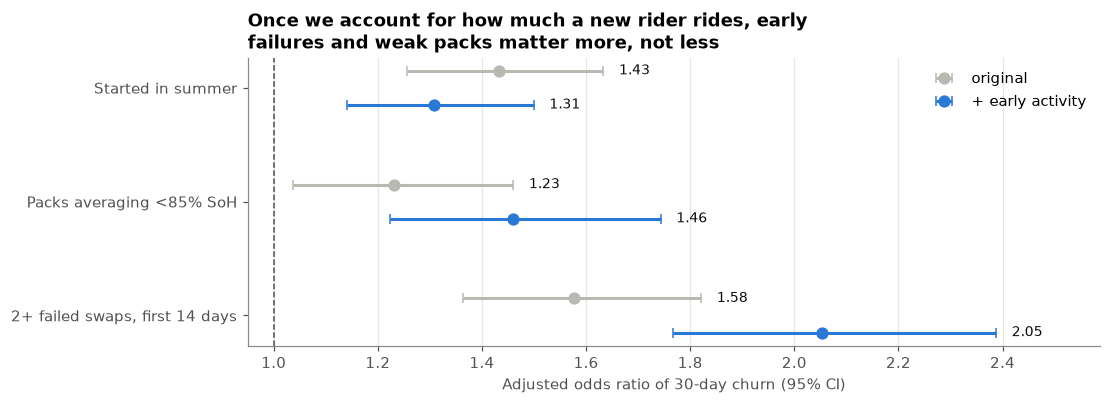

odds_ratio  ci_low  ci_high    p
+ promo & heat promo30        0.90    0.58     1.40 0.63
               tmax30         1.01    0.99     1.02 0.34

odds_ratio  ci_low  ci_high    p
original         fail2plus           1.58    1.36     1.82 0.00
                 low_soh_pack        1.23    1.04     1.46 0.02
                 summer_start        1.43    1.26     1.63 0.00
+ early activity fail2plus           2.05    1.77     2.39 0.00
                 low_soh_pack        1.46    1.22     1.74 0.00
                 summer_start        1.31    1.14     1.50 0.00

In [25]:
m1 = smf.logit(FORM + " + log_n14", data=rf).fit(disp=False)
m2 = smf.logit(FORM.replace("fail2plus", "fail_rate10") + " + log_n14", data=rf).fit(disp=False)
m3 = smf.logit(FORM + " + log_n14 + promo30 + tmax30", data=rf).fit(disp=False)
KEYS = ["fail2plus", "low_soh_pack", "summer_start"]
cmp = pd.concat({"original": ors(m0, KEYS), "+ early activity": ors(m1, KEYS)}, axis=0)
keep("or_fail2plus_adjusted", np.exp(m1.params["fail2plus"])); keep("or_low_soh_adjusted", np.exp(m1.params["low_soh_pack"])); keep("or_summer_adjusted", np.exp(m1.params["summer_start"]))
keep("or_fail_rate_per10pts", np.exp(m2.params["fail_rate10"])); keep("or_promo30", np.exp(m3.params["promo30"])); keep("p_promo30", m3.pvalues["promo30"])
keep("or_tmax30_per_c", np.exp(m3.params["tmax30"])); keep("p_tmax30", m3.pvalues["tmax30"]); keep("pseudo_r2_original", m0.prsquared); keep("pseudo_r2_adjusted", m1.prsquared)
LAB = {"fail2plus": "2+ failed swaps, first 14 days", "low_soh_pack": "Packs averaging <85% SoH", "summer_start": "Started in summer"}
fig, ax = plt.subplots(figsize=(10, 3.4))
for j, (model, col, off) in enumerate([("original", GREY, 0.15), ("+ early activity", BLUE, -0.15)]):
    d = cmp.loc[model]
    for i, k in enumerate(KEYS):
        ax.errorbar(d.loc[k, "odds_ratio"], i + off, xerr=[[d.loc[k, "odds_ratio"] - d.loc[k, "ci_low"]], [d.loc[k, "ci_high"] - d.loc[k, "odds_ratio"]]], fmt="o", color=col, ms=7, capsize=3, label=model if i == 0 else None)
        ax.text(d.loc[k, "ci_high"] + 0.03, i + off, f"{d.loc[k, 'odds_ratio']:.2f}", va="center", fontsize=9, color=INK)
ax.set_yticks(range(3)); ax.set_yticklabels([LAB[k] for k in KEYS]); ax.axvline(1, color=INK2, ls="--", lw=1); ax.grid(axis="y", visible=False)
ax.set_xlabel("Adjusted odds ratio of 30-day churn (95% CI)"); ax.legend(loc="upper right"); ax.set_xlim(0.95, cmp.ci_high.max() + 0.2)
ax.set_title("Once we account for how much a new rider rides, early failures and weak packs matter more, not less")
save(fig, "a09_churn_or_adjusted")
display(pd.concat({"+ promo & heat": ors(m3, ["promo30", "tmax30"])}).round(3))
cmp.round(3)

*Caveat:* early activity is partly an **outcome** (a rider who quits on day 5 has few swaps), so the adjusted odds ratios are an upper bound and the original ones a lower bound. The truth sits between them; either way the published numbers are not overstated.

In [26]:
dr = rf.groupby(pd.cut(100 * rf.fails14 / rf.n14, [-0.01, 0, 10, 20, 100], labels=["0%", "1–10%", "10–20%", ">20%"]), observed=True).churn30.agg(["size", "mean"])
dr.columns = ["riders", "churn_pct"]; dr["churn_pct"] *= 100; dr.index.name = "share of first-14-day attempts that failed"
keep("churn_fail_rate_over20", dr.churn_pct.iloc[-1]); keep("churn_fail_rate_zero", dr.churn_pct.iloc[0])
# riders saved: original method (lower bound) vs model counterfactual with early activity held fixed (upper bound)
saved_low = rf.fail2plus.sum() * (rf[rf.fail2plus == 1].churn30.mean() - rf[rf.fail2plus == 0].churn30.mean())
saved_high = (m1.predict(rf) - m1.predict(rf.assign(fail2plus=0))).sum()
keep("riders_saved_low", saved_low); keep("riders_saved_high", saved_high)
print(f"Riders kept per {len(rf):,} new riders if nobody had 2+ early failures: {saved_low:.0f} (published method) to {saved_high:.0f} (activity-adjusted)")
dr.round(1)

Riders kept per 13,797 new riders if nobody had 2+ early failures: 135 (published method) to 156 (activity-adjusted)


,riders,churn_pct
share of first-14-day attempts that failed,,
0%,7350,9.10
1–10%,4050,7.40
10–20%,1810,14.40
>20%,587,23.30


### 7.3 Cohort trend: which intake churned worst, and do our drivers explain it?

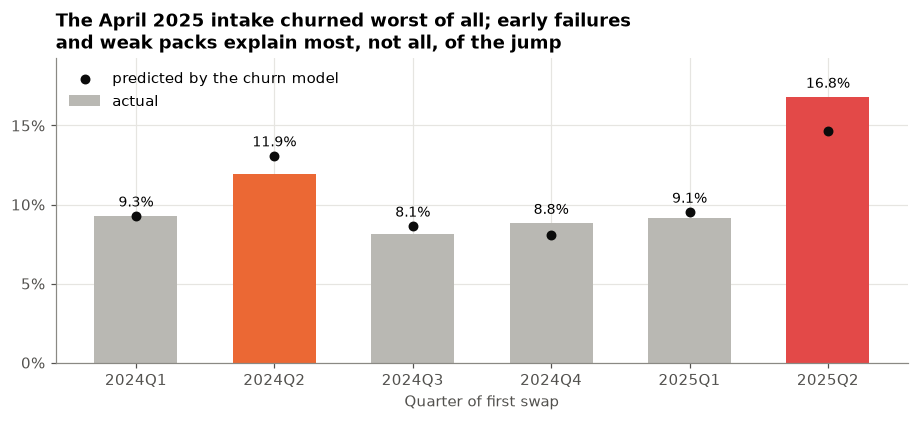

,riders,churn_pct,low_soh,fail2,predicted_by_model_pct
cohort,,,,,
2024Q1,1750,9.30,0.00,11.40,9.30
2024Q2,2094,11.90,0.00,32.40,13.10
2024Q3,2529,8.10,0.00,11.30,8.60
2024Q4,3270,8.80,0.00,12.10,8.10
2025Q1,3046,9.10,29.50,12.60,9.50
2025Q2,1108,16.80,77.50,27.20,14.60


In [27]:
co = rf.groupby("cohort").agg(riders=("churn30", "size"), churn_pct=("churn30", "mean"), low_soh=("low_soh_pack", "mean"), fail2=("fail2plus", "mean"))
co[["churn_pct", "low_soh", "fail2"]] *= 100; co.index = pd.to_datetime(co.index).to_period("Q").astype(str)
rf["pred"] = m1.predict(rf); pr = rf.groupby("cohort").pred.mean() * 100; co["predicted_by_model_pct"] = pr.values
keep("churn_q2_2025", co.loc["2025Q2", "churn_pct"]); keep("churn_q2_2024", co.loc["2024Q2", "churn_pct"]); keep("pred_q2_2025", co.loc["2025Q2", "predicted_by_model_pct"])
keep("low_soh_share_q2_2025", co.loc["2025Q2", "low_soh"])
fig, ax = plt.subplots(figsize=(10, 3.6)); x = np.arange(len(co))
ax.bar(x, co.churn_pct, color=[RED if i == "2025Q2" else (ORANGE if i == "2024Q2" else GREY) for i in co.index], width=0.6, label="actual")
ax.scatter(x, co.predicted_by_model_pct, color=INK, zorder=3, s=30, label="predicted by the churn model")
for i, (v, pv) in enumerate(zip(co.churn_pct, co.predicted_by_model_pct)): ax.text(i, max(v, pv) + 0.6, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_ylim(0, co[["churn_pct", "predicted_by_model_pct"]].values.max() + 2.5)
ax.set_xticks(x); ax.set_xticklabels(co.index); ax.set_xlabel("Quarter of first swap"); pct_axis(ax); ax.legend(loc="upper left")
ax.set_title("The April 2025 intake churned worst of all; early failures and weak packs explain most, not all, of the jump")
save(fig, "a10_churn_by_cohort")
co.round(1)

In [28]:
comp = q('''WITH c AS (SELECT station_id, competitor_within_1_5km_since::DATE d FROM stations WHERE competitor_within_1_5km_since IS NOT NULL)
            SELECT COUNT(DISTINCT c.station_id) stations, SUM(done) FILTER (WHERE ts::DATE BETWEEN d - 60 AND d - 1) / 60.0 / COUNT(DISTINCT c.station_id) swaps_per_day_60d_before,
                   SUM(done) FILTER (WHERE ts::DATE BETWEEN d AND d + 59) / 60.0 / COUNT(DISTINCT c.station_id) swaps_per_day_60d_after FROM sw JOIN c USING(station_id)''')
keep("competitor_station_volume_change_pct", 100 * (comp.swaps_per_day_60d_after[0] / comp.swaps_per_day_60d_before[0] - 1))
comp.round(1)

,stations,swaps_per_day_60d_before,swaps_per_day_60d_after
0,10,45.70,51.10


### ⬆️ Finding: the churn drivers are understated, not overstated
- **Exposure bias:** riders who ride more see more failures but churn less. In the most active fifth of new riders, 22% had 2+ early failures and 6.9% churned; in the least active fifth, 12% and 18.0%. This biases the failure effect *down*.
- **Controlling for early activity:** 2+ failures goes from OR 1.58 to **2.05**, and weak packs from 1.23 to **1.46**. Summer start falls from 1.43 to 1.31, because part of the 'summer' effect was really failures. Activity is partly an outcome itself, so read these as an upper bound and the published figures as a lower bound.
- **Dose-response:** new riders whose early failure rate exceeded 20% churned at **23.3%**, vs 9.1% with no failures.
- **Riders saved** if nobody had 2+ early failures: **135–156 per 13.8K new riders**.
- **Not drivers:** competitor promotions (OR 0.90, p = 0.63), city heat beyond the summer flag (p = 0.34) and nearby competitor openings (those stations' volume *rose* 12%).
- **The worst intake:** riders who started in April 2025 churned at **16.8%** vs 11.9% a year earlier. The model predicts 14.6%, so our drivers explain most but not all of it.
- **Caveat on weak packs:** no 2024 cohort ever received packs averaging <85% SoH, while 78% of the April-2025 intake did. The weak-pack effect is estimated from 2025 riders only, so it stays a *contributing* factor rather than a primary one.

## 8. Scorecard: every headline claim after re-checking

In [29]:
P = lambda k, d=np.nan: PUBLISHED.get(k, d)
S = METRICS
score = pd.DataFrame([
  ("Gen1 × heat drives summer failures", f"Gen1 {P('gen1_summer_fail'):.1f}% vs Gen3 {P('gen3_summer_fail'):.1f}% in summer",
   f"Holds at every load level (Gen1 ≥{S['gen1_fail_min_quartile']:.1f}% vs Gen3 ≤{S['gen3_fail_max_quartile']:.1f}%); Gen3 sites are busier; outages and offline chargers ruled out", "✅ Holds"),
  ("Worst 20% of stations = 43% of failures", f"{P('top20pct_station_fail_share'):.0f}% of failures",
   f"They hold {S['top20_att_share']:.0f}% of attempts (1.4× concentration). Better stat: {S['hot_gen1_stations']} hot-city Gen1 stations = {S['hot_gen1_summer_fail_share']:.0f}% of summer failures", "⚠️ Overstated framing"),
  ("Heat threshold at 45°C", f"stock-outs {P('gen1_stockout_hot'):.0f}% of hours above 45°C",
   f"Holds for failures: {S['gen1_day_fail_below43']:.1f}% on days peaking below 43°C vs {S['gen1_day_fail_46plus']:.1f}% at 46°C+. Stock-out hours peak later ({S['gen1_stockout_45c']:.0f}% at 45°C, {S['gen1_stockout_50c']:.0f}% at 50°C)", "✅ Holds (refined)"),
  ("3W fails more because fewer stations have 3W slots", "narrative claim",
   f"3W failure is the same with or without 3W slots; the gap exists all year ({S['fail_3w_rest']:.1f}% vs {S['fail_2w_rest']:.1f}% outside summer)", "❌ Unsupported"),
  ("Failures rose faster than swaps (brief's premise)", "not challenged",
   f"H1-25 vs H1-24: failures {S['h1_fail_count_growth_x']:.1f}×, completed swaps {S['h1_completed_growth_x']:.1f}×; no month of 2025 is worse than 2024", "➕ Add"),
  ("Gen1→Gen3 avoids ≈22.6K failures a year", f"{P('fails_avoided_per_year'):,.0f}",
   f"Holds; worth ≈₹{S['gen3_replacement_revenue_m_per_year']:.1f}M revenue a year, since a failure never triggers a retry (a rider's next attempt comes at the same time as after a success). Cooling cabinets 5°C could get ~{S['cooling_5c_pct_of_gen3']:.0f}% of the benefit first", "✅ Holds, ➕ monetise"),
  ("Stop buying Kyron", "supplier-level recommendation",
   f"Only lots KY-2407/08/09 are bad ({S['kyron_2w_bad_loss_1k']:.0f} SoH pts per 1K swaps); later Kyron 3W lots wear like Cellora ({S['kyron_3w_later_loss_1k']:.0f} vs {S['cellora_3w_loss_1k']:.0f})", "⚠️ Overreach: lot problem"),
  ("≈₹48M of Kyron packs written off + ₹34M/yr excess wear", f"₹{P('kyron_writeoff_m'):.0f}M and ₹{P('kyron_excess_wear_m_per_year'):.0f}M/yr",
   f"Same money counted twice. 2W packs = ₹{S['writeoff_2w_m']:.1f}M; premature loss ≈₹{S['kyron_premature_loss_m']:.1f}M; not a recurring saving once packs are pulled", "⚠️ Overstated"),
  ("Kyron degradation is real, not heat or usage", "supplier split",
   f"Kyron SoH identical across 6 cities (spread {S['kyron_soh_city_spread']:.1f} pts); returned at the same SoC; ~{S['kyron_km_gap_same_soh_pct']:.0f}% fewer km even at equal SoH", "✅ Holds (stronger)"),
  ("Energy saved ₹3.4 per swap (margin bridge)", f"+₹{P('bridge_energy'):.1f}",
   f"kWh per 2W swap fell {S['kwh_2w_h1_24']:.2f} → {S['kwh_2w_h1_25']:.2f} because packs aged (SoH {S['soh_2w_h1_24']:.0f}% → {S['soh_2w_h1_25']:.0f}%): riders got less energy", "⚠️ Mislabelled"),
  ("Margin eroded to −₹17.5 per swap (H1-25)", inr(P('cm_h1_2025')),
   f"Without the bad lots it would be {inr(S['cm_h1_25_without_bad_lots'])}: ~{S['cm_gap_share_from_bad_lots']:.0f}% of the loss is one bad-lot cohort", "➕ Add context"),
  ("ZipDrop exclusive: no", f"CM {inr(P('zipdrop_cm_h1_25'))} per swap",
   f"Negative even before site costs ({inr(S['zipdrop_variable_margin'])}); the 28% discount bought no share ({S['zipdrop_share_before']:.1f}% → {S['zipdrop_share_after']:.1f}%)", "✅ Holds (stronger)"),
  ("Pricing rollout +₹6.1M a year", f"₹{P('pricing_rollout_m_per_year'):.1f}M",
   f"Pilot riders swapped {abs(S['did_swaps_pct']):.1f}% less often; revenue per rider +{S['did_rev_per_rider_pct']:.1f}% (not +{S['did_rev_per_swap_pct']:.1f}%) → ≈₹{S['pricing_rollout_m_revised']:.1f}M", "⚠️ Overstated"),
  ("2+ early failures → churn OR 1.58", f"OR {P('or_fail2plus'):.2f}",
   f"OR {S['or_fail2plus_adjusted']:.2f} once early activity is controlled; weak packs {S['or_low_soh_adjusted']:.2f}; >20% early failures → {S['churn_fail_rate_over20']:.0f}% churn", "⬆️ Understated"),
  ("≈135 riders saved per 13.8K", f"{P('riders_saved_if_no_early_failures'):.0f}",
   f"{S['riders_saved_low']:.0f}–{S['riders_saved_high']:.0f} (lower and upper bound)", "⬆️ Understated"),
  ("Retention fell (brief)", "retention curves only",
   f"April-2025 intake churned {S['churn_q2_2025']:.1f}% vs {S['churn_q2_2024']:.1f}% a year earlier; model predicts {S['pred_q2_2025']:.1f}%, so part is unexplained", "➕ Add"),
  ("Competitor activity is not a driver", "competitor-nearby only",
   f"Competitor promos OR {S['or_promo30']:.2f} (p={S['p_promo30']:.2f}); stations near a new competitor changed volume {S['competitor_station_volume_change_pct']:+.0f}%", "✅ Holds (extended)"),
  ("Firmware clock fix +5h30m", "hour-of-day curves",
   f"Confirmed by billing: PEAK-tariff swaps inside peak windows {S['fw_peak_in_window_logged']:.0f}% → {S['fw_peak_in_window_fixed']:.0f}%", "✅ Holds (stronger)"),
  ("No near-duplicates to drop", "0.16% vs 0.17% repeat rate",
   f"{S['dup_strict_offline']} offline_batch duplicates under three stricter definitions", "✅ Holds"),
], columns=["claim", "original estimate", "after re-check", "verdict"])
keep("claims_checked", len(score))
score.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"})

claim,original estimate,after re-check,verdict
Gen1 × heat drives summer failures,Gen1 12.5% vs Gen3 4.7% in summer,Holds at every load level (Gen1 ≥14.4% vs Gen3 ≤5.2%); Gen3 sites are busier; outages and offline chargers ruled out,✅ Holds
Worst 20% of stations = 43% of failures,43% of failures,They hold 31% of attempts (1.4× concentration). Better stat: 36 hot-city Gen1 stations = 58% of summer failures,⚠️ Overstated framing
Heat threshold at 45°C,stock-outs 37% of hours above 45°C,"Holds for failures: 4.1% on days peaking below 43°C vs 18.7% at 46°C+. Stock-out hours peak later (6% at 45°C, 59% at 50°C)",✅ Holds (refined)
3W fails more because fewer stations have 3W slots,narrative claim,3W failure is the same with or without 3W slots; the gap exists all year (8.6% vs 3.3% outside summer),❌ Unsupported
Failures rose faster than swaps (brief's premise),not challenged,"H1-25 vs H1-24: failures 2.1×, completed swaps 2.4×; no month of 2025 is worse than 2024",➕ Add
Gen1→Gen3 avoids ≈22.6K failures a year,"22,609","Holds; worth ≈₹1.4M revenue a year, since a failure never triggers a retry (a rider's next attempt comes at the same time as after a success). Cooling cabinets 5°C could get ~64% of the benefit first","✅ Holds, ➕ monetise"
Stop buying Kyron,supplier-level recommendation,Only lots KY-2407/08/09 are bad (75 SoH pts per 1K swaps); later Kyron 3W lots wear like Cellora (33 vs 33),⚠️ Overreach: lot problem
≈₹48M of Kyron packs written off + ₹34M/yr excess wear,₹48M and ₹34M/yr,Same money counted twice. 2W packs = ₹44.3M; premature loss ≈₹28.7M; not a recurring saving once packs are pulled,⚠️ Overstated
"Kyron degradation is real, not heat or usage",supplier split,Kyron SoH identical across 6 cities (spread 0.0 pts); returned at the same SoC; ~11% fewer km even at equal SoH,✅ Holds (stronger)
Energy saved ₹3.4 per swap (margin bridge),+₹3.4,kWh per 2W swap fell 2.02 → 1.69 because packs aged (SoH 97% → 81%): riders got less energy,⚠️ Mislabelled


### What changes in the recommendations
| # | Before | After re-check |
|---|---|---|
| 1 | Replace 36 hot-city Gen1 cabinets with Gen3 | **Unchanged**, plus a **cooling retrofit before April** (5°C ≈ 64% of the benefit) and ≈₹1.4M/yr of recovered revenue in the business case |
| 2 | Stop buying Kyron; claim warranty; replace with Cellora/Amptek | **Reject lots KY-2407/08/09 and claim warranty. Physically pull the 1,438 'retired' packs** (still in service) and **replace ≈1,385 2W packs (25% of the 2W fleet, ≈₹44M) before summer.** Allow any supplier, Kyron included, only after lot acceptance tests. Do not route by SoH alone: Kyron packs deliver ~11% fewer km at the same reading. |
| 3 | Protect new riders' first fortnight | **Stronger case:** OR 1.58–2.05; riders with >20% early failures churn at 23%. Add a hard SoH floor (70%) to cabinet dispensing. |
| 4 | Renegotiate ZipDrop, no exclusive | **Unchanged and stronger:** negative even before site costs (−₹19.9/swap), and the 28% discount bought no volume |
| 5 | Peak pricing as a revenue tool, +₹6.1M | **≈₹3.7M a year**; track swaps per rider in rollout cities, since pilot riders swapped 4.6% less |
| 6 | Fix data plumbing | Add: reconcile the asset register with cabinet logs (retired packs still issued), fix `slots_3w`, fix pack-ID reuse |

**Status:** all of these corrections are now applied in the main notebook, the report, the dashboard, the LinkedIn carousel and post, and the video: ₹44M for the 2W packs (never added to the excess-wear figure), 7–9 months to retirement, pricing ≈₹3.7M, no 3W-slot explanation, the energy bridge step relabelled, and '36 hot-city Gen1 stations = 57.5% of summer failures' as the concentration headline. The 'original estimate' column above keeps the pre-audit values on record.

## 9. Export

In [30]:
with open(OUT / "audit_metrics.json", "w") as f: json.dump(METRICS, f, indent=1, default=str)
score.to_csv(OUT / "audit_scorecard.csv", index=False)
print(f"{len(METRICS)} revised metrics → outputs/audit_metrics.json; scorecard → outputs/audit_scorecard.csv")

103 revised metrics → outputs/audit_metrics.json; scorecard → outputs/audit_scorecard.csv
